In [1]:
# GridDefense | Step 1: Install & Import

!pip install pypower -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pypower.api import case14, runpf, ppoption

# Reproducibility - same random results every run
np.random.seed(42)

print("✓ PyPower installed")
print("✓ All libraries imported")

# Load IEEE 14-bus
ppc = case14()

print(f"\n IEEE 14-Bus System Loaded:")
print(f"  Buses     : {ppc['bus'].shape[0]}")
print(f"  Branches  : {ppc['branch'].shape[0]}")
print(f"  Generators: {ppc['gen'].shape[0]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.6/347.6 kB 2.2 MB/s eta 0:00:00
✓ PyPower installed
✓ All libraries imported

 IEEE 14-Bus System Loaded:
  Buses     : 14
  Branches  : 20
  Generators: 5


In [2]:
# GridDefense | Step 2: Explore the IEEE 14-bus Structure
# Understanding what data PYPOWER gives us


print("=" * 55)
print("BUS DATA — first 5 buses")
print("=" * 55)
print(f"Bus matrix shape: {ppc['bus'].shape}")
print(f"Columns: Bus No | Type | Pd | Qd | Gs | Bs | Area | Vm | Va | BaseKV | Zone | Vmax | Vmin")
print()
print(ppc['bus'][:5, :])

print("\n" + "=" * 55)
print("BRANCH DATA — first 5 branches")
print("=" * 55)
print(f"Branch matrix shape: {ppc['branch'].shape}")
print(f"Columns: From | To | R | X | B | RateA | RateB | RateC | ...")
print()
print(ppc['branch'][:5, :5])  # just first 5 columns

print("\n" + "=" * 55)
print("WHAT WE CARE ABOUT:")
print("=" * 55)
print("From bus data:")
print(f"  Vm (voltage magnitude) → column 7")
print(f"  Va (voltage angle)     → column 8")
print(f"  Pd (active power load) → column 2")
print(f"  Qd (reactive power)    → column 3")
print("\nFrom branch data:")
print(f"  From bus → column 0")
print(f"  To bus   → column 1")
print(f"  R (resistance)  → column 2")
print(f"  X (reactance)   → column 3")
print("\nThese are the measurements our PMU sensors would record.")
print("These are what an attacker would manipulate in FDIA.")

BUS DATA — first 5 buses
Bus matrix shape: (14, 13)
Columns: Bus No | Type | Pd | Qd | Gs | Bs | Area | Vm | Va | BaseKV | Zone | Vmax | Vmin

[[  1.      3.      0.      0.      0.      0.      1.      1.06    0.
    0.      1.      1.06    0.94 ]
 [  2.      2.     21.7    12.7     0.      0.      1.      1.045  -4.98
    0.      1.      1.06    0.94 ]
 [  3.      2.     94.2    19.      0.      0.      1.      1.01  -12.72
    0.      1.      1.06    0.94 ]
 [  4.      1.     47.8    -3.9     0.      0.      1.      1.019 -10.33
    0.      1.      1.06    0.94 ]
 [  5.      1.      7.6     1.6     0.      0.      1.      1.02   -8.78
    0.      1.      1.06    0.94 ]]

BRANCH DATA — first 5 branches
Branch matrix shape: (20, 13)
Columns: From | To | R | X | B | RateA | RateB | RateC | ...

[[1.      2.      0.01938 0.05917 0.0528 ]
 [1.      5.      0.05403 0.22304 0.0492 ]
 [2.      3.      0.04699 0.19797 0.0438 ]
 [2.      4.      0.05811 0.17632 0.034  ]
 [2.      5.      0.05

In [3]:
# GridDefense | Step 3: Run Power Flow & Extract Measurements
# This is what ONE timestep of PMU data looks like


# Set PYPOWER options - suppress output
opt = ppoption(VERBOSE=0, OUT_ALL=0)

# Run AC power flow
result = runpf(ppc, opt)

# Extract the solved case
solved = result[0]
success = result[1]

print(f"Power flow converged: {bool(success)}")
print()

# Extract measurements from all 14 buses
bus_data = solved['bus']

# Our 4 key measurements per bus
Vm = bus_data[:, 7]   # Voltage magnitude (pu)
Va = bus_data[:, 8]   # Voltage angle (degrees)
Pd = bus_data[:, 2]   # Active power load (MW)
Qd = bus_data[:, 3]   # Reactive power load (MVAr)

print("=" * 45)
print("PMU Measurements — All 14 Buses")
print("=" * 45)
print(f"{'Bus':>4} {'Vm(pu)':>8} {'Va(deg)':>8} {'Pd(MW)':>8} {'Qd(MVAr)':>10}")
print("-" * 45)
for i in range(14):
    print(f"{i+1:>4} {Vm[i]:>8.4f} {Va[i]:>8.3f} {Pd[i]:>8.2f} {Qd[i]:>10.2f}")

print()
print(f"Total active load:    {Pd.sum():.2f} MW")
print(f"Total reactive load:  {Qd.sum():.2f} MVAr")
print()
print("This is what ONE timestep of normal PMU data looks like.")
print("We will generate 5000 of these with varying loads.")

Power flow converged: True

PMU Measurements — All 14 Buses
 Bus   Vm(pu)  Va(deg)   Pd(MW)   Qd(MVAr)
---------------------------------------------
   1   1.0600    0.000     0.00       0.00
   2   1.0450   -4.983    21.70      12.70
   3   1.0100  -12.725    94.20      19.00
   4   1.0177  -10.313    47.80      -3.90
   5   1.0195   -8.774     7.60       1.60
   6   1.0700  -14.221    11.20       7.50
   7   1.0615  -13.360     0.00       0.00
   8   1.0900  -13.360     0.00       0.00
   9   1.0559  -14.939    29.50      16.60
  10   1.0510  -15.097     9.00       5.80
  11   1.0569  -14.791     3.50       1.80
  12   1.0552  -15.076     6.10       1.60
  13   1.0504  -15.156    13.50       5.80
  14   1.0355  -16.034    14.90       5.00

Total active load:    259.00 MW
Total reactive load:  73.50 MVAr

This is what ONE timestep of normal PMU data looks like.
We will generate 5000 of these with varying loads.


In [4]:
# GridDefense | Step 4: Generate Normal Dataset
# 5000 timesteps with realistic load variation
# Gaussian noise σ = 0.005 p.u.

from copy import deepcopy

# Dataset parameters
N_NORMAL = 5000
LOAD_MIN = 0.80
LOAD_MAX = 1.20
NOISE_STD = 0.005

# Store base loads from original case
base_Pd = ppc['bus'][:, 2].copy()  # base active load per bus
base_Qd = ppc['bus'][:, 3].copy()  # base reactive load per bus

print(f"Generating {N_NORMAL} normal samples...")
print(f"Load variation: {LOAD_MIN*100}% to {LOAD_MAX*100}% of base")
print(f"Gaussian noise: σ = {NOISE_STD} p.u.")
print()

# Storage for our dataset
normal_data = []
failed_count = 0

opt = ppoption(VERBOSE=0, OUT_ALL=0)

for i in range(N_NORMAL):

    # Deep copy so we don't modify the original
    ppc_copy = deepcopy(ppc)

    # Per-bus load scaling — consistent with attack generation
    load_factor = np.random.uniform(LOAD_MIN, LOAD_MAX, size=14)
    ppc_copy['bus'][:, 2] = base_Pd * load_factor
    ppc_copy['bus'][:, 3] = base_Qd * load_factor

    # Run AC power flow
    result = runpf(ppc_copy, opt)
    solved = result[0]
    success = result[1]

    # Only keep converged solutions
    if not success:
        failed_count += 1
        continue

    # Extract measurements from all 14 buses
    bus_data = solved['bus']
    Vm = bus_data[:, 7]   # voltage magnitude
    Va = bus_data[:, 8]   # voltage angle
    Pd = bus_data[:, 2]   # active power
    Qd = bus_data[:, 3]   # reactive power

    # Stack into one flat measurement vector
    # Shape: (56,) = 14 buses × 4 measurements
    measurement = np.concatenate([Vm, Va, Pd, Qd])

    # Add Gaussian noise (Luo et al. 2025)
    noise = np.random.normal(0, NOISE_STD, measurement.shape)
    measurement = measurement + noise

    normal_data.append(measurement)

    # Progress update every 500 samples
    if (i + 1) % 500 == 0:
        print(f"  {i+1}/{N_NORMAL} samples generated...")

# Convert to numpy array
normal_data = np.array(normal_data)

print(f"\n✓ Normal dataset generated!")
print(f"  Shape: {normal_data.shape}")
print(f"  Samples: {normal_data.shape[0]}")
print(f"  Features per sample: {normal_data.shape[1]}")
print(f"  Failed power flows: {failed_count}")
print(f"\n  Features breakdown:")
print(f"  [0:14]  → Voltage magnitude (Vm) for all 14 buses")
print(f"  [14:28] → Voltage angle (Va) for all 14 buses")
print(f"  [28:42] → Active power (Pd) for all 14 buses")
print(f"  [42:56] → Reactive power (Qd) for all 14 buses")

Generating 5000 normal samples...
Load variation: 80.0% to 120.0% of base
Gaussian noise: σ = 0.005 p.u.

  500/5000 samples generated...
  1000/5000 samples generated...
  1500/5000 samples generated...
  2000/5000 samples generated...
  2500/5000 samples generated...
  3000/5000 samples generated...
  3500/5000 samples generated...
  4000/5000 samples generated...
  4500/5000 samples generated...
  5000/5000 samples generated...

✓ Normal dataset generated!
  Shape: (5000, 56)
  Samples: 5000
  Features per sample: 56
  Failed power flows: 0

  Features breakdown:
  [0:14]  → Voltage magnitude (Vm) for all 14 buses
  [14:28] → Voltage angle (Va) for all 14 buses
  [28:42] → Active power (Pd) for all 14 buses
  [42:56] → Reactive power (Qd) for all 14 buses


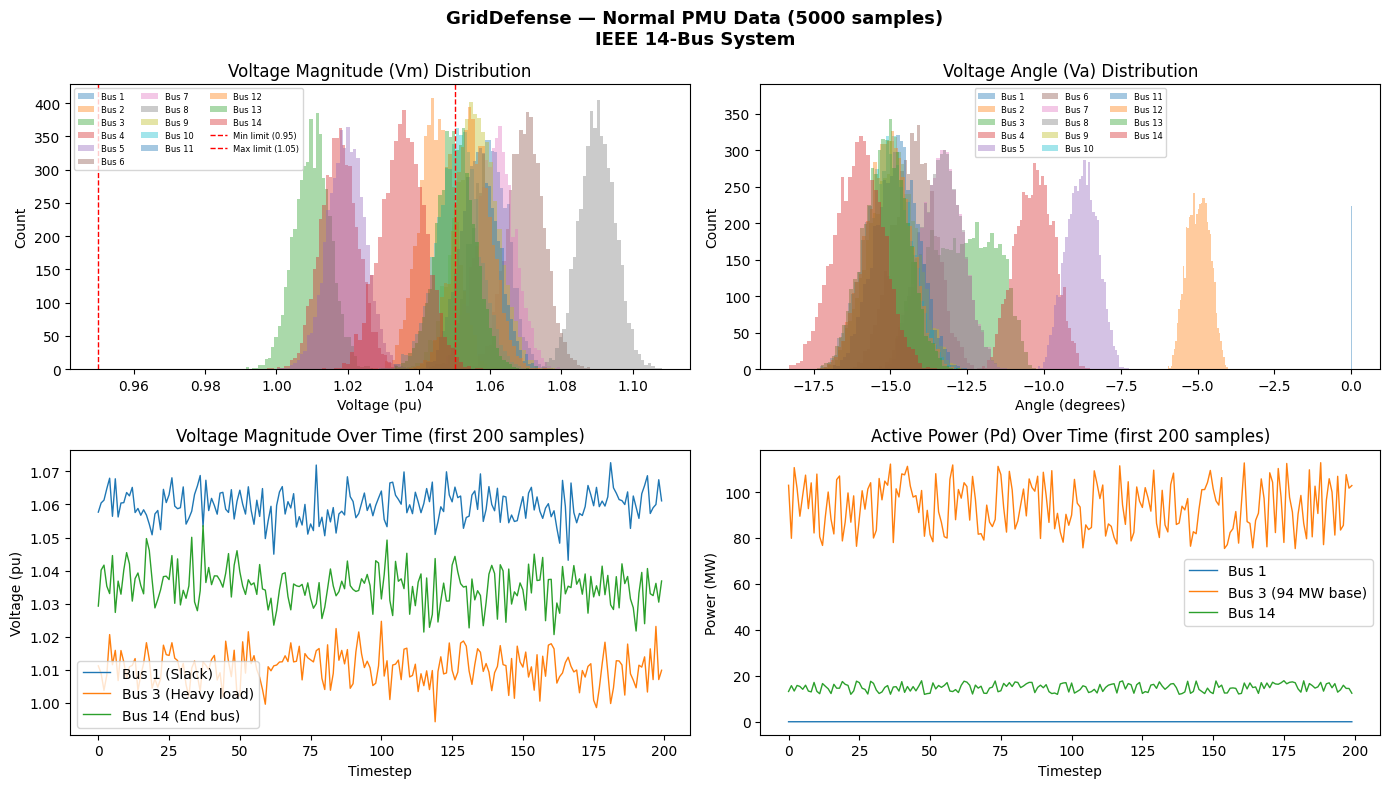

✓ Visualization saved!

What we're seeing:
  Top left:  Voltage magnitudes cluster around 1.0 pu — physically correct
  Top right: Angles spread negative from Bus 1 — physically correct
  Bottom:    Natural variation from load scaling — realistic PMU behaviour



In [5]:
# GridDefense | Step 5: Visualise Normal Data
# Verify our dataset looks physically realistic


fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('GridDefense — Normal PMU Data (5000 samples)\nIEEE 14-Bus System',
             fontsize=13, fontweight='bold')

# --- Plot 1: Voltage Magnitude distribution across all buses ---
ax1 = axes[0, 0]
for bus in range(14):
    ax1.hist(normal_data[:, bus], bins=40, alpha=0.4, label=f'Bus {bus+1}')
ax1.set_title('Voltage Magnitude (Vm) Distribution')
ax1.set_xlabel('Voltage (pu)')
ax1.set_ylabel('Count')
ax1.axvline(x=0.95, color='red', linestyle='--', linewidth=1, label='Min limit (0.95)')
ax1.axvline(x=1.05, color='red', linestyle='--', linewidth=1, label='Max limit (1.05)')
ax1.legend(fontsize=6, ncol=3)

# --- Plot 2: Voltage Angle distribution ---
ax2 = axes[0, 1]
for bus in range(14):
    ax2.hist(normal_data[:, 14+bus], bins=40, alpha=0.4, label=f'Bus {bus+1}')
ax2.set_title('Voltage Angle (Va) Distribution')
ax2.set_xlabel('Angle (degrees)')
ax2.set_ylabel('Count')
ax2.legend(fontsize=6, ncol=3)

# --- Plot 3: Voltage magnitude over time for key buses ---
ax3 = axes[1, 0]
ax3.plot(normal_data[:200, 0],  label='Bus 1 (Slack)', linewidth=1)
ax3.plot(normal_data[:200, 2],  label='Bus 3 (Heavy load)', linewidth=1)
ax3.plot(normal_data[:200, 13], label='Bus 14 (End bus)', linewidth=1)
ax3.set_title('Voltage Magnitude Over Time (first 200 samples)')
ax3.set_xlabel('Timestep')
ax3.set_ylabel('Voltage (pu)')
ax3.legend()

# --- Plot 4: Active power over time ---
ax4 = axes[1, 1]
ax4.plot(normal_data[:200, 28],  label='Bus 1', linewidth=1)
ax4.plot(normal_data[:200, 30],  label='Bus 3 (94 MW base)', linewidth=1)
ax4.plot(normal_data[:200, 41],  label='Bus 14', linewidth=1)
ax4.set_title('Active Power (Pd) Over Time (first 200 samples)')
ax4.set_xlabel('Timestep')
ax4.set_ylabel('Power (MW)')
ax4.legend()

plt.tight_layout()
plt.savefig('normal_data_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualization saved!")
print()
print("What we're seeing:")
print("  Top left:  Voltage magnitudes cluster around 1.0 pu — physically correct")
print("  Top right: Angles spread negative from Bus 1 — physically correct")
print("  Bottom:    Natural variation from load scaling — realistic PMU behaviour")
print()

In [6]:
# GridDefense | Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

import os

# Create GridDefense folders on your Drive
base_path = '/content/drive/MyDrive/GridDefense'
os.makedirs(f'{base_path}/data', exist_ok=True)
os.makedirs(f'{base_path}/models', exist_ok=True)
os.makedirs(f'{base_path}/results', exist_ok=True)

print("✓ Google Drive mounted")
print("✓ GridDefense folders created")
print(f"\nYour data will be saved to:")
print(f"  {base_path}/data/")

# Save normal data immediately — don't lose it
np.save(f'{base_path}/data/normal_data.npy', normal_data)
print(f"\n✓ Normal data saved to Drive!")
print(f"  File: normal_data.npy")
print(f"  Shape: {normal_data.shape}")

Mounted at /content/drive
✓ Google Drive mounted
✓ GridDefense folders created

Your data will be saved to:
  /content/drive/MyDrive/GridDefense/data/

✓ Normal data saved to Drive!
  File: normal_data.npy
  Shape: (5000, 56)


In [7]:
# GridDefense | Step 6: Build Graph Structure
# Bus = node, Transmission line = edge

# Extract branch (transmission line) data
branch_data = ppc['branch']

# From bus and To bus for each of the 20 branches
from_bus = branch_data[:, 0].astype(int) - 1  # -1 because Python is 0-indexed
to_bus   = branch_data[:, 1].astype(int) - 1

# Line impedances (physics of each edge)
resistance  = branch_data[:, 2]  # R
reactance   = branch_data[:, 3]  # X
impedance   = np.sqrt(resistance**2 + reactance**2)  # |Z| = sqrt(R² + X²)

# Build adjacency matrix (14 × 14)
# adj[i][j] = 1 if bus i and bus j are connected
adj_matrix = np.zeros((14, 14))
for i in range(len(from_bus)):
    f = from_bus[i]
    t = to_bus[i]
    adj_matrix[f, t] = 1
    adj_matrix[t, f] = 1  # undirected graph

# Build edge index (2 × 40) — PyTorch Geometric format
# 20 branches × 2 directions = 40 edges
edge_index = []
edge_weights = []
for i in range(len(from_bus)):
    f = from_bus[i]
    t = to_bus[i]
    # Add both directions
    edge_index.append([f, t])
    edge_index.append([t, f])
    edge_weights.append(impedance[i])
    edge_weights.append(impedance[i])

edge_index   = np.array(edge_index).T  # shape (2, 40)
edge_weights = np.array(edge_weights)   # shape (40,)

print("✓ Graph structure built!")
print(f"\n  Adjacency matrix shape : {adj_matrix.shape}")
print(f"  Edge index shape       : {edge_index.shape}")
print(f"  Edge weights shape     : {edge_weights.shape}")
print(f"\n  Connections per bus:")
for i in range(14):
    neighbours = np.where(adj_matrix[i] == 1)[0] + 1
    print(f"    Bus {i+1:2d} → connected to buses {list(neighbours)}")

# Save graph structure
np.save('/content/drive/MyDrive/GridDefense/data/adj_matrix.npy',   adj_matrix)
np.save('/content/drive/MyDrive/GridDefense/data/edge_index.npy',   edge_index)
np.save('/content/drive/MyDrive/GridDefense/data/edge_weights.npy', edge_weights)
print("\n✓ Graph structure saved to Drive!")

✓ Graph structure built!

  Adjacency matrix shape : (14, 14)
  Edge index shape       : (2, 40)
  Edge weights shape     : (40,)

  Connections per bus:
    Bus  1 → connected to buses [np.int64(2), np.int64(5)]
    Bus  2 → connected to buses [np.int64(1), np.int64(3), np.int64(4), np.int64(5)]
    Bus  3 → connected to buses [np.int64(2), np.int64(4)]
    Bus  4 → connected to buses [np.int64(2), np.int64(3), np.int64(5), np.int64(7), np.int64(9)]
    Bus  5 → connected to buses [np.int64(1), np.int64(2), np.int64(4), np.int64(6)]
    Bus  6 → connected to buses [np.int64(5), np.int64(11), np.int64(12), np.int64(13)]
    Bus  7 → connected to buses [np.int64(4), np.int64(8), np.int64(9)]
    Bus  8 → connected to buses [np.int64(7)]
    Bus  9 → connected to buses [np.int64(4), np.int64(7), np.int64(10), np.int64(14)]
    Bus 10 → connected to buses [np.int64(9), np.int64(11)]
    Bus 11 → connected to buses [np.int64(6), np.int64(10)]
    Bus 12 → connected to buses [np.int64(6), n

In [8]:
# ============================================================
# GridDefense | Step 7 FIXED v2 — Attack Injection
# ============================================================

import pandas as pd
import numpy as np
from pypower.api import case14, runpf, ppoption
from copy import deepcopy

ppopt = ppoption(VERBOSE=0, OUT_ALL=0)

# ── Parameters ───────────────────────────────────────────────
N_ATTACK   = 1000
ATTACK_MAX = 0.02    # 2% max deviation
NOISE_STD  = 0.005   # same as normal data
LOAD_MIN   = 0.80
LOAD_MAX   = 1.20

# Slack bus = Bus 1 (index 0) — not attackable
SLACK_BUS  = 0
ATTACKABLE = [b for b in range(14) if b != SLACK_BUS]

print(f"Attack parameters:")
print(f"  Max deviation   : {ATTACK_MAX*100}%")
print(f"  Load range      : {LOAD_MIN*100}% to {LOAD_MAX*100}%")
print(f"  Noise std       : {NOISE_STD} p.u.")
print(f"  Protected buses : [1] (slack bus)")
print(f"  Attackable buses: {[b+1 for b in ATTACKABLE]}")
print()

# Base loads from IEEE 14-bus
base_ppc  = case14()
base_Pd_v = base_ppc['bus'][:, 2].copy()  # base active load
base_Qd_v = base_ppc['bus'][:, 3].copy()  # base reactive load

branch = base_ppc['branch']
n_bus  = base_ppc['bus'].shape[0]
adj_matrix = np.zeros((n_bus, n_bus), dtype=int)
for f_bus, t_bus in branch[:, :2]:
    f_idx, t_idx = int(f_bus) - 1, int(t_bus) - 1  # case14 buses are 1-indexed
    adj_matrix[f_idx, t_idx] = 1
    adj_matrix[t_idx, f_idx] = 1

# Column names for 56 core features
cols_56 = (
    [f'Vm_{i+1}' for i in range(14)] +
    [f'Va_{i+1}' for i in range(14)] +
    [f'Pd_{i+1}' for i in range(14)] +
    [f'Qd_{i+1}' for i in range(14)]
)

vm_cols = [f'Vm_{i+1}' for i in range(14)]

# ── Helper: run one power flow ────────────────────────────────
def run_one_pf(load_factor_array):
    ppc = case14()
    ppc['bus'][:, 2] = base_Pd_v * load_factor_array
    ppc['bus'][:, 3] = base_Qd_v * load_factor_array
    result, success  = runpf(ppc, ppopt)
    if not success:
        return None
    return result

# ── Stage A: Additive FDIA ───────────────────────────────────
print(f"Generating Additive FDIA ({N_ATTACK} samples)...")
add_meas   = []
add_blabel = []

while len(add_meas) < N_ATTACK:
    lf     = np.random.uniform(LOAD_MIN, LOAD_MAX, size=14)
    result = run_one_pf(lf)
    if result is None:
        continue

    Vm_val = result['bus'][:, 7].copy()
    Va_val = result['bus'][:, 8].copy()
    Pd_val = result['bus'][:, 2].copy()
    Qd_val = result['bus'][:, 3].copy()

    n_buses = np.random.randint(1, 4)
    t_buses = np.random.choice(ATTACKABLE, n_buses, replace=False)
    blabel  = np.zeros(14)

    for bus in t_buses:
        bias        = np.random.uniform(0.005, ATTACK_MAX)
        sign        = np.random.choice([-1, 1])
        Vm_val[bus] += sign * bias * Vm_val[bus]
        Va_val[bus] += sign * bias * abs(Va_val[bus]) \
                       if Va_val[bus] != 0 else sign * bias
        blabel[bus]  = 1

    meas  = np.concatenate([Vm_val, Va_val, Pd_val, Qd_val])
    noise = np.random.normal(0, NOISE_STD, meas.shape)
    meas  = meas + noise

    add_meas.append(meas)
    add_blabel.append(blabel)

add_meas   = np.array(add_meas)
add_blabel = np.array(add_blabel)
print(f"  ✓ {len(add_meas)} samples done")

# ── Stage B: Scaling FDIA ────────────────────────────────────
print(f"Generating Scaling FDIA ({N_ATTACK} samples)...")
scale_meas   = []
scale_blabel = []

while len(scale_meas) < N_ATTACK:
    lf     = np.random.uniform(LOAD_MIN, LOAD_MAX, size=14)
    result = run_one_pf(lf)
    if result is None:
        continue

    Vm_val = result['bus'][:, 7].copy()
    Va_val = result['bus'][:, 8].copy()
    Pd_val = result['bus'][:, 2].copy()
    Qd_val = result['bus'][:, 3].copy()

    n_buses = np.random.randint(1, 4)
    t_buses = np.random.choice(ATTACKABLE, n_buses, replace=False)
    blabel  = np.zeros(14)

    for bus in t_buses:
        # Scale Vm only — not Va
        # Breaks AC Q equation specifically
        k = np.random.uniform(1.005, 1.02)
        if np.random.choice([True, False]):
            k = 1 / k
        Vm_val[bus] *= k
        blabel[bus]  = 1

    meas  = np.concatenate([Vm_val, Va_val, Pd_val, Qd_val])
    noise = np.random.normal(0, NOISE_STD, meas.shape)
    meas  = meas + noise

    scale_meas.append(meas)
    scale_blabel.append(blabel)

scale_meas   = np.array(scale_meas)
scale_blabel = np.array(scale_blabel)
print(f"  ✓ {len(scale_meas)} samples done")

# ── Stage C: Coordinated Multi-Bus FDIA ──────────────────────
print(f"Generating Coordinated FDIA ({N_ATTACK} samples)...")
coord_meas   = []
coord_blabel = []

while len(coord_meas) < N_ATTACK:
    lf     = np.random.uniform(LOAD_MIN, LOAD_MAX, size=14)
    result = run_one_pf(lf)
    if result is None:
        continue

    Vm_val = result['bus'][:, 7].copy()
    Va_val = result['bus'][:, 8].copy()
    Pd_val = result['bus'][:, 2].copy()
    Qd_val = result['bus'][:, 3].copy()

    # Center bus must not be slack
    center     = np.random.choice(ATTACKABLE)
    neighbours = list(np.where(adj_matrix[center] == 1)[0])
    neighbours = [n for n in neighbours if n != SLACK_BUS]

    if len(neighbours) == 0:
        continue

    n_nb        = min(np.random.randint(1, 3), len(neighbours))
    att_nb      = np.random.choice(neighbours, n_nb, replace=False)
    all_attacked = [center] + list(att_nb)
    blabel       = np.zeros(14)

    base_bias = np.random.uniform(0.005, ATTACK_MAX)
    sign      = np.random.choice([-1, 1])

    for bus in all_attacked:
        bias        = base_bias * np.random.uniform(0.8, 1.0)
        Vm_val[bus] += sign * bias * Vm_val[bus]
        Va_val[bus] += sign * bias * abs(Va_val[bus]) \
                       if Va_val[bus] != 0 else sign * bias
        blabel[bus]  = 1

    meas  = np.concatenate([Vm_val, Va_val, Pd_val, Qd_val])
    noise = np.random.normal(0, NOISE_STD, len(meas))
    meas  = meas + noise

    coord_meas.append(meas)
    coord_blabel.append(blabel)

coord_meas   = np.array(coord_meas)
coord_blabel = np.array(coord_blabel)
print(f"  ✓ {len(coord_meas)} samples done")

# ── Build df_attacked ─────────────────────────────────────────
print()
print("=" * 55)
print("Building df_attacked...")

df_add   = pd.DataFrame(add_meas,   columns=cols_56)
df_scl   = pd.DataFrame(scale_meas, columns=cols_56)
df_crd   = pd.DataFrame(coord_meas, columns=cols_56)

# Add bus labels
for i in range(14):
    df_add[f'bus_label_{i+1}'] = add_blabel[:, i]
    df_scl[f'bus_label_{i+1}'] = scale_blabel[:, i]
    df_crd[f'bus_label_{i+1}'] = coord_blabel[:, i]

# Add metadata
df_add['Attack_Type'] = 1
df_scl['Attack_Type'] = 2
df_crd['Attack_Type'] = 3

df_add['Label'] = 1
df_scl['Label'] = 1
df_crd['Label'] = 1

# Combine
df_attacked = pd.concat([df_add, df_scl, df_crd], ignore_index=True)
print("\n" + "=" * 60)
print("RAW STEP 7 — BEFORE STEP 8")
print("=" * 60)

print("Shape:", df_attacked.shape)

print("Number of columns:", len(df_attacked.columns))

print("\nPhysics columns present:")
print([
    c for c in df_attacked.columns
    if c.startswith(("P_res_", "Q_res_", "LineFlow_", "BusBalance_"))
])

print("\nVm range:")
print(
    df_attacked[vm_cols].values.min(),
    "to",
    df_attacked[vm_cols].values.max()
)

print(f"✓ df_attacked shape : {df_attacked.shape}")
print(f"  Additive (1)     : {(df_attacked['Attack_Type']==1).sum()}")
print(f"  Scaling (2)      : {(df_attacked['Attack_Type']==2).sum()}")
print(f"  Coordinated (3)  : {(df_attacked['Attack_Type']==3).sum()}")
print(f"  Total            : {len(df_attacked)}")
print()

# ── Stealthiness check ────────────────────────────────────────
print("Stealthiness verification:")

# Normal Vm stats (from normal_data generated in Step 4)
# NOTE: normal_data is not defined in this script — it must still be
# in scope from your earlier Step 4 cell/run for this section to work.
normal_vm = normal_data[:, :14]  # first 14 cols are Vm
norm_min  = normal_vm.min()
norm_max  = normal_vm.max()
norm_mean = normal_vm.mean()

print(f"  Normal Vm range : {norm_min:.4f} to {norm_max:.4f}")
print(f"  Normal Vm mean  : {norm_mean:.4f}")
print()

for atype, name in [(1,'Additive'),(2,'Scaling'),(3,'Coordinated')]:
    subset    = df_attacked[df_attacked['Attack_Type']==atype]
    vm_vals   = subset[vm_cols].values
    att_min   = vm_vals.min()
    att_max   = vm_vals.max()
    att_mean  = vm_vals.mean()
    diff_pct  = abs(att_mean - norm_mean) / norm_mean * 100
    overlap   = att_min < norm_max and att_max > norm_min
    print(f"  {name}:")
    print(f"    Vm range   : {att_min:.4f} to {att_max:.4f}")
    print(f"    Mean diff  : {diff_pct:.3f}%")
    print(f"    Overlaps with normal: {overlap} ← must be True for stealth")
    print()

print("✓ Step 7 complete — df_attacked ready for Step 8")

Attack parameters:
  Max deviation   : 2.0%
  Load range      : 80.0% to 120.0%
  Noise std       : 0.005 p.u.
  Protected buses : [1] (slack bus)
  Attackable buses: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

Generating Additive FDIA (1000 samples)...
  ✓ 1000 samples done
Generating Scaling FDIA (1000 samples)...
  ✓ 1000 samples done
Generating Coordinated FDIA (1000 samples)...
  ✓ 1000 samples done

Building df_attacked...

RAW STEP 7 — BEFORE STEP 8
Shape: (3000, 72)
Number of columns: 72

Physics columns present:
[]

Vm range:
0.9796765736442603 to 1.1248979092933171
✓ df_attacked shape : (3000, 72)
  Additive (1)     : 1000
  Scaling (2)      : 1000
  Coordinated (3)  : 1000
  Total            : 3000

Stealthiness verification:
  Normal Vm range : 0.9914 to 1.1081
  Normal Vm mean  : 1.0485

  Additive:
    Vm range   : 0.9797 to 1.1249
    Mean diff  : 0.003%
    Overlaps with normal: True ← must be True for stealth

  Scaling:
    Vm range   : 0.9877 to 1.1218
    Mean dif

In [13]:
import pandas as pd

df_normal = pd.read_csv(
    '/content/drive/MyDrive/GridDefense/data/df_normal_raw.csv'
)

df_attacked = pd.read_csv(
    '/content/drive/MyDrive/GridDefense/data/df_attacked_raw.csv'
)

print("df_normal:", df_normal.shape)
print("df_attacked:", df_attacked.shape)

df_normal: (5000, 72)
df_attacked: (3000, 72)


In [17]:
# ============================================================
# Diagnostic: is Additive-vs-Coordinated confusion caused by
# topological overlap, or by noise / weak localization?
# ============================================================

import numpy as np

bus_cols = [f'bus_label_{i}' for i in range(1, 15)]

def has_adjacent_pair(buses):
    buses = list(buses)
    return any(adj_matrix[buses[i], buses[j]] == 1
               for i in range(len(buses)) for j in range(i + 1, len(buses)))

# 1. How often does Additive land on adjacent buses in the CURRENT data?
add = df_full[df_full['Attack_Type'] == 1]
add_adj = np.array([has_adjacent_pair(np.where(r == 1)[0])
                    for r in add[bus_cols].values])
print(f"Additive samples with an adjacent bus pair: "
      f"{add_adj.sum()}/{len(add)} ({add_adj.mean()*100:.1f}%)")

# 2. Where does the GNN's Additive->Coordinated confusion actually sit?
assert len(sample_pred) == len(test_idx), "sample_pred and test_idx are out of sync"
test_df = df_full.iloc[list(test_idx)].reset_index(drop=True)
test_df['pred'] = sample_pred

sub = test_df[test_df['Attack_Type'] == 1].copy()
sub['adjacent'] = [has_adjacent_pair(np.where(r == 1)[0])
                   for r in sub[bus_cols].values]
sub['n_buses'] = sub[bus_cols].sum(axis=1).astype(int)

print("\nTrue Additive samples in test set, split by bus count")
print("(1-bus Additive can NEVER overlap with Coordinated):")
for k in [1, 2, 3]:
    g = sub[sub['n_buses'] == k]
    if len(g):
        print(f"  {k} bus(es): n={len(g):3d} | "
              f"predicted Additive: {(g['pred']==1).mean()*100:5.1f}% | "
              f"predicted Scaling: {(g['pred']==2).mean()*100:5.1f}% | "
              f"predicted Coordinated: {(g['pred']==3).mean()*100:5.1f}%")

print("\nTrue Additive samples, split by adjacency (2-3 bus only):")
multi = sub[sub['n_buses'] >= 2]
for flag, name in [(True, 'has adjacent pair'), (False, 'no adjacent pair')]:
    g = multi[multi['adjacent'] == flag]
    if len(g):
        print(f"  {name:18}: n={len(g):3d} | "
              f"predicted Coordinated: {(g['pred']==3).mean()*100:5.1f}% | "
              f"predicted Additive: {(g['pred']==1).mean()*100:5.1f}%")

print("""
HOW TO READ THIS:
- If 1-bus Additive is often predicted Coordinated, topology overlap
  is NOT the cause (that overlap is impossible by construction).
  The confusion is noise / weak localization -> keep Step 7 as is.
- If 'has adjacent pair' is predicted Coordinated much more often than
  'no adjacent pair', overlap contributes something. Then it's a
  judgment call, and it's still a legitimate limitation to report
  rather than something you must fix.
""")

Additive samples with an adjacent bus pair: 290/1000 (29.0%)

True Additive samples in test set, split by bus count
(1-bus Additive can NEVER overlap with Coordinated):
  1 bus(es): n= 48 | predicted Additive:  18.8% | predicted Scaling:  77.1% | predicted Coordinated:   4.2%
  2 bus(es): n= 47 | predicted Additive:  61.7% | predicted Scaling:  27.7% | predicted Coordinated:  10.6%
  3 bus(es): n= 55 | predicted Additive:  65.5% | predicted Scaling:  20.0% | predicted Coordinated:  14.5%

True Additive samples, split by adjacency (2-3 bus only):
  has adjacent pair : n= 45 | predicted Coordinated:  20.0% | predicted Additive:  60.0%
  no adjacent pair  : n= 57 | predicted Coordinated:   7.0% | predicted Additive:  66.7%

HOW TO READ THIS:
- If 1-bus Additive is often predicted Coordinated, topology overlap
  is NOT the cause (that overlap is impossible by construction).
  The confusion is noise / weak localization -> keep Step 7 as is.
- If 'has adjacent pair' is predicted Coordinated 

In [ ]:
print("NORMAL COLUMNS:")
print(df_normal.columns.tolist())

print("\nATTACKED COLUMNS:")
print(df_attacked.columns.tolist())

print("\nSame columns?")
print(df_normal.columns.equals(df_attacked.columns))

NORMAL COLUMNS:
['Vm_1', 'Vm_2', 'Vm_3', 'Vm_4', 'Vm_5', 'Vm_6', 'Vm_7', 'Vm_8', 'Vm_9', 'Vm_10', 'Vm_11', 'Vm_12', 'Vm_13', 'Vm_14', 'Va_1', 'Va_2', 'Va_3', 'Va_4', 'Va_5', 'Va_6', 'Va_7', 'Va_8', 'Va_9', 'Va_10', 'Va_11', 'Va_12', 'Va_13', 'Va_14', 'Pd_1', 'Pd_2', 'Pd_3', 'Pd_4', 'Pd_5', 'Pd_6', 'Pd_7', 'Pd_8', 'Pd_9', 'Pd_10', 'Pd_11', 'Pd_12', 'Pd_13', 'Pd_14', 'Qd_1', 'Qd_2', 'Qd_3', 'Qd_4', 'Qd_5', 'Qd_6', 'Qd_7', 'Qd_8', 'Qd_9', 'Qd_10', 'Qd_11', 'Qd_12', 'Qd_13', 'Qd_14', 'bus_label_1', 'bus_label_2', 'bus_label_3', 'bus_label_4', 'bus_label_5', 'bus_label_6', 'bus_label_7', 'bus_label_8', 'bus_label_9', 'bus_label_10', 'bus_label_11', 'bus_label_12', 'bus_label_13', 'bus_label_14', 'Attack_Type', 'Label']

ATTACKED COLUMNS:
['Vm_1', 'Vm_2', 'Vm_3', 'Vm_4', 'Vm_5', 'Vm_6', 'Vm_7', 'Vm_8', 'Vm_9', 'Vm_10', 'Vm_11', 'Vm_12', 'Vm_13', 'Vm_14', 'Va_1', 'Va_2', 'Va_3', 'Va_4', 'Va_5', 'Va_6', 'Va_7', 'Va_8', 'Va_9', 'Va_10', 'Va_11', 'Va_12', 'Va_13', 'Va_14', 'Pd_1', 'Pd_2', 'Pd_3'

In [ ]:
print("===== NORMAL LABEL CHECK =====")
print("Label:")
print(df_normal['Label'].value_counts(dropna=False))

print("\nAttack_Type:")
print(df_normal['Attack_Type'].value_counts(dropna=False))

print("\nBus labels:")
print(df_normal[[f'bus_label_{i}' for i in range(1, 15)]].sum().sum())


print("\n===== ATTACKED LABEL CHECK =====")
print("Label:")
print(df_attacked['Label'].value_counts(dropna=False))

print("\nAttack_Type:")
print(df_attacked['Attack_Type'].value_counts(dropna=False))

print("\nBus labels:")
print(df_attacked[[f'bus_label_{i}' for i in range(1, 15)]].sum().sum())

===== NORMAL LABEL CHECK =====
Label:
Label
0    5000
Name: count, dtype: int64

Attack_Type:
Attack_Type
0.0    5000
Name: count, dtype: int64

Bus labels:
0.0

===== ATTACKED LABEL CHECK =====
Label:
Label
1    3000
Name: count, dtype: int64

Attack_Type:
Attack_Type
1    1000
2    1000
3    1000
Name: count, dtype: int64

Bus labels:
6489.0


In [ ]:
print("Bus 1 attacked labels:",
      df_attacked['bus_label_1'].sum())

print("Any Bus 1 attacks?",
      df_attacked['bus_label_1'].sum() > 0)

Bus 1 attacked labels: 0.0
Any Bus 1 attacks? False


In [ ]:
# ============================================================
# PERMANENT FIX — Save raw data before Step 8
# ============================================================

# Save df_normal (56 core features + labels, NO physics yet)
core_normal_cols = (
    [f'Vm_{i+1}' for i in range(14)] +
    [f'Va_{i+1}' for i in range(14)] +
    [f'Pd_{i+1}' for i in range(14)] +
    [f'Qd_{i+1}' for i in range(14)] +
    [f'bus_label_{i+1}' for i in range(14)] +
    ['Attack_Type', 'Label']
)

# Save df_attacked (core features + labels, NO physics yet)
core_attack_cols = (
    [f'Vm_{i+1}' for i in range(14)] +
    [f'Va_{i+1}' for i in range(14)] +
    [f'Pd_{i+1}' for i in range(14)] +
    [f'Qd_{i+1}' for i in range(14)] +
    [f'bus_label_{i+1}' for i in range(14)] +
    ['Attack_Type', 'Label']
)

# Get clean versions
df_normal_clean   = df_normal[[c for c in core_normal_cols
                                if c in df_normal.columns]].copy()
df_attacked_clean = df_attacked[[c for c in core_attack_cols
                                  if c in df_attacked.columns]].copy()

# Make sure Label is correct
df_normal_clean['Label']   = 0
df_attacked_clean['Label'] = 1

print(f"df_normal_clean   : {df_normal_clean.shape}")
print(f"df_attacked_clean : {df_attacked_clean.shape}")

# Save to Drive
df_normal_clean.to_csv(
    '/content/drive/MyDrive/GridDefense/data/df_normal_raw.csv',
    index=False
)
df_attacked_clean.to_csv(
    '/content/drive/MyDrive/GridDefense/data/df_attacked_raw.csv',
    index=False
)

print()
print("✓ df_normal_raw.csv saved to Drive")
print("✓ df_attacked_raw.csv saved to Drive")
print()
print("From now on — if Colab resets, just run:")
print("  df_normal   = pd.read_csv('.../df_normal_raw.csv')")
print("  df_attacked = pd.read_csv('.../df_attacked_raw.csv')")
print("Then rerun Step 8 — everything works cleanly")

df_normal_clean   : (5000, 72)
df_attacked_clean : (3000, 72)

✓ df_normal_raw.csv saved to Drive
✓ df_attacked_raw.csv saved to Drive

From now on — if Colab resets, just run:
  df_normal   = pd.read_csv('.../df_normal_raw.csv')
  df_attacked = pd.read_csv('.../df_attacked_raw.csv')
Then rerun Step 8 — everything works cleanly


In [ ]:
# Step 8: feature engineering

import numpy as np
import pandas as pd

from pypower.case14 import case14
from pypower.ext2int import ext2int
from pypower.makeYbus import makeYbus

# Remove time_idx if present from previous interleaving
df_normal   = df_normal.drop(columns=['time_idx'], errors='ignore')
df_attacked = df_attacked.drop(columns=['time_idx'], errors='ignore')
# ============================================================
# 1. CHECK EXISTING DATA FROM STEP 7
# ============================================================

print("=" * 60)
print("STEP 8 — FEATURE ENGINEERING")
print("=" * 60)

print("\nExisting normal data:")
print(df_normal.shape)

print("\nExisting attack data:")
print(df_attacked.shape)


# ============================================================
# 2. REMOVE OLD PHYSICS FEATURES
# ============================================================

old_physics_cols = [
    col for col in df_normal.columns
    if (
        col.startswith("P_res_")
        or col.startswith("Q_res_")
        or col.startswith("LineFlow_")
        or col.startswith("BusBalance_")
    )
]

old_physics_cols += [
    col for col in df_attacked.columns
    if (
        col.startswith("P_res_")
        or col.startswith("Q_res_")
        or col.startswith("LineFlow_")
        or col.startswith("BusBalance_")
    )
]

old_physics_cols = list(set(old_physics_cols))

df_normal = df_normal.drop(
    columns=old_physics_cols,
    errors="ignore"
)

df_attacked = df_attacked.drop(
    columns=old_physics_cols,
    errors="ignore"
)

print("\n✓ Old physics features removed")


# ============================================================
# 3. LOAD IEEE 14-BUS NETWORK
# ============================================================

base_ppc = case14()

baseMVA = base_ppc["baseMVA"]

# Convert external bus numbering:
# 1,2,...,14
#
# to internal PYPOWER numbering:
# 0,1,...,13

ppc_int = ext2int(
    base_ppc.copy()
)

bus_data = ppc_int["bus"]
branch_data = ppc_int["branch"]

nb = len(bus_data)
n_branches = len(branch_data)


# ============================================================
# 4. BUILD Y-BUS
# ============================================================

Ybus, Yf, Yt = makeYbus(
    baseMVA,
    bus_data,
    branch_data
)

if hasattr(Ybus, "toarray"):
    Ybus = Ybus.toarray()

G = np.real(Ybus)
B = np.imag(Ybus)


# ============================================================
# 5. BRANCH INFORMATION
# ============================================================

from_buses = branch_data[:, 0].astype(int)
to_buses = branch_data[:, 1].astype(int)

reactance = branch_data[:, 3]


print("\n✓ IEEE 14-bus network loaded")
print("  Buses:", nb)
print("  Branches:", n_branches)
print("  Y-bus:", Ybus.shape)


# ============================================================
# 6. EXTRACT ELECTRICAL FEATURES
# ============================================================

Vm_normal = df_normal[
    [f"Vm_{i}" for i in range(1, 15)]
].values

Va_normal = np.radians(
    df_normal[
        [f"Va_{i}" for i in range(1, 15)]
    ].values
)

Pd_normal = df_normal[
    [f"Pd_{i}" for i in range(1, 15)]
].values

Qd_normal = df_normal[
    [f"Qd_{i}" for i in range(1, 15)]
].values


Vm_attack = df_attacked[
    [f"Vm_{i}" for i in range(1, 15)]
].values

Va_attack = np.radians(
    df_attacked[
        [f"Va_{i}" for i in range(1, 15)]
    ].values
)

Pd_attack = df_attacked[
    [f"Pd_{i}" for i in range(1, 15)]
].values

Qd_attack = df_attacked[
    [f"Qd_{i}" for i in range(1, 15)]
].values


# ============================================================
# 7. AC POWER CALCULATION
# ============================================================

def calculate_ac_power(
    Vm,
    Va
):

    P_calc = np.zeros(
        (len(Vm), nb)
    )

    Q_calc = np.zeros(
        (len(Vm), nb)
    )

    for i in range(nb):

        for j in range(nb):

            dtheta = (
                Va[:, i]
                - Va[:, j]
            )

            P_calc[:, i] += (
                Vm[:, i]
                * Vm[:, j]
                * (
                    G[i, j] * np.cos(dtheta)
                    +
                    B[i, j] * np.sin(dtheta)
                )
            )

            Q_calc[:, i] += (
                Vm[:, i]
                * Vm[:, j]
                * (
                    G[i, j] * np.sin(dtheta)
                    -
                    B[i, j] * np.cos(dtheta)
                )
            )

    return P_calc, Q_calc


# Normal
P_normal, Q_normal = calculate_ac_power(
    Vm_normal,
    Va_normal
)

# Attack
P_attack, Q_attack = calculate_ac_power(
    Vm_attack,
    Va_attack
)


# Convert per-unit → MW / MVAr

P_normal = P_normal * baseMVA
Q_normal = Q_normal * baseMVA

P_attack = P_attack * baseMVA
Q_attack = Q_attack * baseMVA


print("\n✓ AC power calculations complete")
# ============================================================
# 8A. AC NET-INJECTION FEATURES
# ============================================================

for i in range(nb):

    df_normal[f"P_res_{i+1}"] = P_normal[:, i]
    df_normal[f"Q_res_{i+1}"] = Q_normal[:, i]

    df_attacked[f"P_res_{i+1}"] = P_attack[:, i]
    df_attacked[f"Q_res_{i+1}"] = Q_attack[:, i]

print("✓ 28 AC-derived P/Q features added")

# ============================================================
# 8. PHYSICS-BASED FEATURES
# ============================================================

# ============================================================
# AC LINE FLOW FEATURES — PYPOWER Yf
# ============================================================

def calculate_ac_line_flows(Vm, Va):
    """
    Calculate AC active power flow (MW) for every branch
    for every sample using PYPOWER's Yf matrix.
    """

    n_samples = len(Vm)
    flows = np.zeros((n_samples, n_branches))

    for r in range(n_samples):

        # Complex bus voltages for this sample
        V_complex = Vm[r] * np.exp(1j * Va[r])

        # Current flowing from the "from" side of each branch
        If = Yf.dot(V_complex)

        # Complex power flow
        Sf = V_complex[from_buses] * np.conj(If) * baseMVA

        # Active power flow in MW
        flows[r, :] = np.real(Sf)

    return flows


# Calculate AC line flows
normal_line_flows = calculate_ac_line_flows(
    Vm_normal,
    Va_normal
)

attack_line_flows = calculate_ac_line_flows(
    Vm_attack,
    Va_attack
)


# Add the 20 line-flow features
for i in range(n_branches):
    df_normal[f"LineFlow_{i+1}"] = normal_line_flows[:, i]
    df_attacked[f"LineFlow_{i+1}"] = attack_line_flows[:, i]


print("AC line-flow features added successfully.")
print("Normal line flows:", normal_line_flows.shape)
print("Attack line flows:", attack_line_flows.shape)
print("Number of line-flow features:", n_branches)

# ============================================================
# 9. BUS-BALANCE FEATURES
# ============================================================

def calculate_bus_balance(
    Pd,
    line_flow
):

    net_flow = np.zeros(
        (len(Pd), nb)
    )

    for k in range(n_branches):

        net_flow[
            :,
            from_buses[k]
        ] += line_flow[:, k]

        net_flow[
            :,
            to_buses[k]
        ] -= line_flow[:, k]

    bus_balance = (
        -Pd - net_flow
    )

    return bus_balance


balance_normal = calculate_bus_balance(
    Pd_normal,
    normal_line_flows  # ← correct variable name
)

balance_attack = calculate_bus_balance(
    Pd_attack,
    attack_line_flows  # ← correct variable name
)

# Add 14 bus-balance features

for i in range(nb):

    df_normal[
        f"BusBalance_{i+1}"
    ] = balance_normal[:, i]

    df_attacked[
        f"BusBalance_{i+1}"
    ] = balance_attack[:, i]


print("✓ 14 bus-balance features added")


# ============================================================
# 10. COMBINE NORMAL + ATTACK
# ============================================================

df_full = pd.concat(
    [
        df_normal,
        df_attacked
    ],
    ignore_index=True
)


# ============================================================
# 11. FINAL FEATURE LIST
# ============================================================

excluded_columns = [
    "Label",
    "Attack_Type",
    "time_idx"
]

excluded_columns += [
    f"bus_label_{i}"
    for i in range(1, 15)
]

model_features = [
    col
    for col in df_full.columns
    if col not in excluded_columns
]
# ============================================================
# 12. FEATURE GROUP CHECK
# ============================================================

electrical_features = [
    col for col in model_features
    if (
        col.startswith("Vm_")
        or col.startswith("Va_")
        or col.startswith("Pd_")
        or col.startswith("Qd_")
    )
]

residual_features = [
    col for col in model_features
    if (
        col.startswith("P_res_")
        or col.startswith("Q_res_")
    )
]

line_features = [
    col for col in model_features
    if col.startswith("LineFlow_")
]

balance_features = [
    col for col in model_features
    if col.startswith("BusBalance_")
]

expected_features = (
    electrical_features
    + residual_features
    + line_features
    + balance_features
)
# ============================================================
# CHECK EXACT MODEL FEATURES
# ============================================================

extra_features = [
    col for col in model_features
    if col not in expected_features
]

missing_features = [
    col for col in expected_features
    if col not in model_features
]

print("\n" + "=" * 60)
print("FEATURE COUNT DEBUG")
print("=" * 60)

print("Expected features :", len(expected_features))
print("Actual model features:", len(model_features))

print("\nExtra feature(s):")
print(extra_features)

print("\nMissing feature(s):")
print(missing_features)

# ============================================================
# 13. FINAL CHECK
# ============================================================

print("\n" + "=" * 60)
print("STEP 8 COMPLETE")
print("=" * 60)

print("\nDataset:")
print("  Rows:", len(df_full))
print("  Total columns:", len(df_full.columns))

print("\nFeature groups:")
print("  Electrical features :", len(electrical_features))
print("  P/Q residuals       :", len(residual_features))
print("  Line-flow features  :", len(line_features))
print("  Bus-balance features:", len(balance_features))
print("  --------------------------------")
print("  Model features      :", len(model_features))

print("\nLabels:")
print(df_full["Label"].value_counts())

print("\nAttack types:")
print(
    df_full["Attack_Type"]
    .value_counts()
    .sort_index()
)

print(
    "\nMissing model values:",
    df_full[model_features].isna().sum().sum()
)


# ============================================================
# 14. AC POWER DIAGNOSTIC
# ============================================================

print("\n" + "=" * 60)
print("NORMAL AC POWER DIAGNOSTIC")
print("=" * 60)

for i in range(1, 15):

    print(
        f"Bus {i:2d}: "
        f"P mean={P_normal[:, i-1].mean():.4f}, "
        f"max={P_normal[:, i-1].max():.4f} | "
        f"Q mean={Q_normal[:, i-1].mean():.4f}, "
        f"max={Q_normal[:, i-1].max():.4f}"
    )


# ============================================================
# 15. SAVE
# ============================================================

save_path = (
    "/content/drive/MyDrive/"
    "GridDefense/data/"
    "griddefense_dataset_final.csv"
)

df_full.to_csv(
    save_path,
    index=False
)

print("\n✓ Saved:")
print(save_path)

STEP 8 — FEATURE ENGINEERING

Existing normal data:
(5000, 72)

Existing attack data:
(3000, 72)

✓ Old physics features removed

✓ IEEE 14-bus network loaded
  Buses: 14
  Branches: 20
  Y-bus: (14, 14)

✓ AC power calculations complete
✓ 28 AC-derived P/Q features added
AC line-flow features added successfully.
Normal line flows: (5000, 20)
Attack line flows: (3000, 20)
Number of line-flow features: 20
✓ 14 bus-balance features added

FEATURE COUNT DEBUG
Expected features : 118
Actual model features: 118

Extra feature(s):
[]

Missing feature(s):
[]

STEP 8 COMPLETE

Dataset:
  Rows: 8000
  Total columns: 134

Feature groups:
  Electrical features : 56
  P/Q residuals       : 28
  Line-flow features  : 20
  Bus-balance features: 14
  --------------------------------
  Model features      : 118

Labels:
Label
0    5000
1    3000
Name: count, dtype: int64

Attack types:
Attack_Type
0.0    5000
1.0    1000
2.0    1000
3.0    1000
Name: count, dtype: int64

Missing model values: 0

NORMA

In [ ]:
import os

base = "/content/drive/MyDrive/GridDefense"

for root, dirs, files in os.walk(base):
    for file in files:
        if file.endswith((".csv", ".parquet", ".pkl", ".h5", ".keras")):
            print(os.path.join(root, file))

/content/drive/MyDrive/GridDefense/data/df_normal_final.csv
/content/drive/MyDrive/GridDefense/data/df_attacked_final.csv
/content/drive/MyDrive/GridDefense/data/griddefense_dataset_final.csv
/content/drive/MyDrive/GridDefense/data/df_attacked_raw.csv
/content/drive/MyDrive/GridDefense/data/df_normal_raw.csv
/content/drive/MyDrive/GridDefense/data/griddefense_dataset.csv
/content/drive/MyDrive/GridDefense/models/ae_model.keras
/content/drive/MyDrive/GridDefense/models/scaler_ae.pkl


In [ ]:
# ============================================================
# FINAL STEP 8 DIAGNOSTIC — LOCK CHECK
# ============================================================

print("=" * 60)
print("STEP 8 — FINAL DIAGNOSTIC / LOCK CHECK")
print("=" * 60)

# ------------------------------------------------------------
# 1. SHAPE + FEATURE COUNT
# ------------------------------------------------------------

print("\n[1] SHAPE CHECK")

print("Normal:", df_normal.shape)
print("Attack:", df_attacked.shape)
print("Full  :", df_full.shape)

print("Model features:", len(model_features))

assert len(model_features) == 118
print("✓ 118 model features confirmed")


# ------------------------------------------------------------
# 2. NaN / INF CHECK
# ------------------------------------------------------------

print("\n[2] NaN / INF CHECK")

nan_count = df_full[model_features].isna().sum().sum()
inf_count = np.isinf(
    df_full[model_features].select_dtypes(include=np.number)
).sum().sum()

print("NaN values:", nan_count)
print("Infinite values:", inf_count)

assert nan_count == 0
assert inf_count == 0

print("✓ No NaN or infinite values")


# ------------------------------------------------------------
# 3. FEATURE GROUP CHECK
# ------------------------------------------------------------

print("\n[3] FEATURE GROUP CHECK")

print("Electrical :", len(electrical_features))
print("P/Q        :", len(residual_features))
print("Line flow  :", len(line_features))
print("Bus balance:", len(balance_features))

assert len(electrical_features) == 56
assert len(residual_features) == 28
assert len(line_features) == 20
assert len(balance_features) == 14

print("✓ Feature groups = 56 + 28 + 20 + 14 = 118")


# ------------------------------------------------------------
# 4. DUPLICATE FEATURE CHECK
# ------------------------------------------------------------

print("\n[4] DUPLICATE CHECK")

duplicate_features = (
    pd.Series(model_features)
    .value_counts()
)

duplicate_features = duplicate_features[
    duplicate_features > 1
]

print("Duplicate feature names:")

if len(duplicate_features) == 0:
    print("None")
    print("✓ No duplicate feature names")
else:
    print(duplicate_features)


# ------------------------------------------------------------
# 5. CONSTANT / NEAR-CONSTANT FEATURES
# ------------------------------------------------------------

print("\n[5] CONSTANT FEATURE CHECK")

feature_std = df_full[model_features].std()

constant_features = feature_std[
    feature_std == 0
].index.tolist()

print("Constant features:", len(constant_features))

if constant_features:
    print(constant_features)
else:
    print("✓ No constant features")


# ------------------------------------------------------------
# 6. NORMAL VS ATTACK FEATURE SHIFT
# ------------------------------------------------------------

print("\n[6] NORMAL vs ATTACK FEATURE SHIFT")

normal_mean = df_normal[model_features].mean()
attack_mean = df_attacked[model_features].mean()

mean_difference = (
    attack_mean - normal_mean
).abs()

largest_changes = mean_difference.sort_values(
    ascending=False
).head(15)

print("\nTop 15 features with largest mean shift:")

for feature, value in largest_changes.items():
    print(f"{feature:25s}: {value:.6f}")


# ------------------------------------------------------------
# 7. LINE FLOW RANGE CHECK
# ------------------------------------------------------------

print("\n[7] AC LINE-FLOW CHECK")

normal_line = df_normal[line_features]
attack_line = df_attacked[line_features]

print(
    "Normal line-flow range:",
    normal_line.min().min(),
    "to",
    normal_line.max().max()
)

print(
    "Attack line-flow range:",
    attack_line.min().min(),
    "to",
    attack_line.max().max()
)

print("✓ Line-flow features contain finite values")


# ------------------------------------------------------------
# 8. BUS-BALANCE RANGE CHECK
# ------------------------------------------------------------

print("\n[8] BUS-DERIVED FEATURE CHECK")

normal_balance = df_normal[balance_features]
attack_balance = df_attacked[balance_features]

print(
    "Normal range:",
    normal_balance.min().min(),
    "to",
    normal_balance.max().max()
)

print(
    "Attack range:",
    attack_balance.min().min(),
    "to",
    attack_balance.max().max()
)

print("✓ Bus-derived features contain finite values")


# ------------------------------------------------------------
# 9. ATTACK LABEL CONSISTENCY
# ------------------------------------------------------------

print("\n[9] LABEL CHECK")

print(
    df_full["Label"].value_counts()
)

print("\nAttack types:")
print(
    df_full["Attack_Type"].value_counts().sort_index()
)

assert set(df_full["Label"].unique()) == {0, 1}

print("✓ Labels are consistent")


# ------------------------------------------------------------
# 10. FINAL LOCK DECISION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL STEP 8 STATUS")
print("=" * 60)

if (
    len(model_features) == 118
    and nan_count == 0
    and inf_count == 0
    and len(constant_features) == 0
):

    print("✓ STEP 8 PASSED BASIC DATA-INTEGRITY CHECKS")
    print("✓ 118 FEATURES")
    print("✓ NO NaN")
    print("✓ NO INFINITE VALUES")
    print("✓ NO CONSTANT FEATURES")
    print("✓ READY TO LOCK STEP 8")

else:

    print("STEP 8 NEEDS REVIEW")

STEP 8 — FINAL DIAGNOSTIC / LOCK CHECK

[1] SHAPE CHECK
Normal: (5000, 134)
Attack: (3000, 134)
Full  : (8000, 134)
Model features: 118
✓ 118 model features confirmed

[2] NaN / INF CHECK
NaN values: 0
Infinite values: 0
✓ No NaN or infinite values

[3] FEATURE GROUP CHECK
Electrical : 56
P/Q        : 28
Line flow  : 20
Bus balance: 14
✓ Feature groups = 56 + 28 + 20 + 14 = 118

[4] DUPLICATE CHECK
Duplicate feature names:
None
✓ No duplicate feature names

[5] CONSTANT FEATURE CHECK
Constant features: 0
✓ No constant features

[6] NORMAL vs ATTACK FEATURE SHIFT

Top 15 features with largest mean shift:
Q_res_9                  : 0.462961
Q_res_5                  : 0.261324
Q_res_1                  : 0.257828
Q_res_13                 : 0.230079
Q_res_10                 : 0.211641
Q_res_6                  : 0.207904
Q_res_4                  : 0.189517
Pd_3                     : 0.180674
Q_res_11                 : 0.178426
BusBalance_5             : 0.174834
P_res_13                 : 0.

In [ ]:
# ============================================================
# GridDefense | Autoencoder — Step 1: Prepare Data
# AE trains on normal data only — unsupervised
# ============================================================

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# AE uses only PMU + physics features (not labels or bus_label)
ae_feature_cols = (
    [f'Vm_{i+1}'         for i in range(14)] +
    [f'Va_{i+1}'         for i in range(14)] +
    [f'Pd_{i+1}'         for i in range(14)] +
    [f'Qd_{i+1}'         for i in range(14)] +
    [f'P_res_{i+1}'      for i in range(14)] +
    [f'Q_res_{i+1}'      for i in range(14)] +
    [f'LineFlow_{i+1}'   for i in range(20)] +
    [f'BusBalance_{i+1}' for i in range(14)]
)

# 90 features total going into AE
print(f"AE input features: {len(ae_feature_cols)}")

# Split normal vs attacked
normal_data_ae   = df_full[df_full['Label'] == 0][ae_feature_cols].values
attacked_data_ae = df_full[df_full['Label'] == 1][ae_feature_cols].values

print(f"Normal samples   : {normal_data_ae.shape}")
print(f"Attacked samples : {attacked_data_ae.shape}")

# Normalize to [0, 1] — critical for AE performance
# Fit scaler on normal data only
scaler = MinMaxScaler()
normal_scaled   = scaler.fit_transform(normal_data_ae)
attacked_scaled = scaler.transform(attacked_data_ae)  # same scaler

# Split normal into train/val/test
X_train, X_temp = train_test_split(normal_scaled, test_size=0.2, random_state=42)
X_val,  X_test_normal = train_test_split(X_temp, test_size=0.5, random_state=42)

print()
print(f"AE Training set  : {X_train.shape}  ← normal only")
print(f"AE Validation    : {X_val.shape}")
print(f"AE Test normal   : {X_test_normal.shape}")
print(f"AE Test attacked : {attacked_scaled.shape}")
print()
print("✓ Data ready for Autoencoder!")
print("Scaler fitted on normal data only — attacked data never seen during training")

AE input features: 118
Normal samples   : (5000, 118)
Attacked samples : (3000, 118)

AE Training set  : (4000, 118)  ← normal only
AE Validation    : (500, 118)
AE Test normal   : (500, 118)
AE Test attacked : (3000, 118)

✓ Data ready for Autoencoder!
Scaler fitted on normal data only — attacked data never seen during training


In [ ]:
# GridDefense | Autoencoder — Step 2: Build Architecture
# Encoder compresses → Bottleneck → Decoder reconstructs
# Trained on normal data only — unsupervised anomaly detection

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set seed for reproducibility
tf.random.set_seed(42)

# Input dimension = 118 features
INPUT_DIM  = X_train.shape[1]  # 118
ENCODING_DIM = 16               # bottleneck size

print(f"Building Autoencoder...")
print(f"  Input dim    : {INPUT_DIM}")
print(f"  Bottleneck   : {ENCODING_DIM}")
print()

# ── Encoder ─────────────────────────────────────────────────
inputs  = keras.Input(shape=(INPUT_DIM,), name='input')
x       = layers.Dense(64,  activation='relu', name='enc_1')(inputs)
x       = layers.Dense(32,  activation='relu', name='enc_2')(x)
encoded = layers.Dense(ENCODING_DIM, activation='relu', name='bottleneck')(x)

# ── Decoder ─────────────────────────────────────────────────
x       = layers.Dense(32,  activation='relu', name='dec_1')(encoded)
x       = layers.Dense(64,  activation='relu', name='dec_2')(x)
outputs = layers.Dense(INPUT_DIM, activation='sigmoid', name='output')(x)

# ── Full Autoencoder ─────────────────────────────────────────
autoencoder = keras.Model(inputs, outputs, name='GridDefense_AE')
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'  # mean squared error — reconstruction loss
)

autoencoder.summary()
print()
print("✓ Autoencoder built")
print()
print("Architecture:")
print("  Input (118)")
print("     ↓  Dense 64, ReLU")
print("     ↓  Dense 32, ReLU")
print("     ↓  Bottleneck: Dense 16, ReLU  ← compressed representation")
print("     ↓  Dense 32, ReLU")
print("     ↓  Dense 64, ReLU")
print("     ↓  Output (118), Sigmoid")
print()
print("Loss function : MSE (mean squared error)")
print("Optimizer     : Adam lr=0.001")
print("Training data : normal only — AE never sees attacks")

Building Autoencoder...
  Input dim    : 118
  Bottleneck   : 16



Model: "GridDefense_AE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 118)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 64)             │         7,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_2 (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 118)            │         7,670 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,550 (80.27 KB)

 Trainable params: 20,550 (80.27 KB)

 Non-trainable params: 0 (0.00 B)


✓ Autoencoder built

Architecture:
  Input (118)
     ↓  Dense 64, ReLU
     ↓  Dense 32, ReLU
     ↓  Bottleneck: Dense 16, ReLU  ← compressed representation
     ↓  Dense 32, ReLU
     ↓  Dense 64, ReLU
     ↓  Output (118), Sigmoid

Loss function : MSE (mean squared error)
Optimizer     : Adam lr=0.001
Training data : normal only — AE never sees attacks


In [ ]:
df_full.to_csv('/content/drive/MyDrive/GridDefense/data/griddefense_dataset.csv', index=False)
np.save('/content/drive/MyDrive/GridDefense/data/X_train.npy', X_train)
np.save('/content/drive/MyDrive/GridDefense/data/X_val.npy', X_val)
np.save('/content/drive/MyDrive/GridDefense/data/X_test_normal.npy', X_test_normal)
np.save('/content/drive/MyDrive/GridDefense/data/attacked_scaled.npy', attacked_scaled)
np.save('/content/drive/MyDrive/GridDefense/data/adj_matrix.npy', adj_matrix)
np.save('/content/drive/MyDrive/GridDefense/data/edge_index.npy', edge_index)

In [ ]:
print("df_normal shape:", df_normal.shape)
print("df_attacked shape:", df_attacked.shape)

print("\nNumber of model features:", len(model_features))
print("First 10 model features:")
print(model_features[:10])

print("\nX_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

print("\nExpected AE input:", autoencoder.input_shape)

df_normal shape: (5000, 134)
df_attacked shape: (3000, 134)

Number of model features: 118
First 10 model features:
['Vm_1', 'Vm_2', 'Vm_3', 'Vm_4', 'Vm_5', 'Vm_6', 'Vm_7', 'Vm_8', 'Vm_9', 'Vm_10']

X_train shape: (4000, 118)
X_val shape: (500, 118)

Expected AE input: (None, 118)


In [ ]:
print("\nMissing model features:")
print([c for c in model_features if c not in df_normal.columns])

print("\nExtra physics columns:")
print([c for c in df_normal.columns
       if c.startswith(("P_res_", "Q_res_", "LineFlow_", "BusBalance_"))][:20])


Missing model features:
[]

Extra physics columns:
['P_res_1', 'Q_res_1', 'P_res_2', 'Q_res_2', 'P_res_3', 'Q_res_3', 'P_res_4', 'Q_res_4', 'P_res_5', 'Q_res_5', 'P_res_6', 'Q_res_6', 'P_res_7', 'Q_res_7', 'P_res_8', 'Q_res_8', 'P_res_9', 'Q_res_9', 'P_res_10', 'Q_res_10']


In [ ]:
# GridDefense | Autoencoder — Step 3: Train
# Input = normal data, Target = same normal data
# AE learns to reconstruct normal grid behaviour

# Callbacks — smart training controls
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

print("=" * 50)
print("Training GridDefense Autoencoder")
print("=" * 50)
print(f"  Training samples : {X_train.shape[0]} (normal only)")
print(f"  Validation       : {X_val.shape[0]}")
print(f"  Input features   : {X_train.shape[1]}")
print(f"  Epochs max       : 100")
print(f"  Batch size       : 32")
print(f"  Early stopping   : patience 10")
print()
print("AE never sees attacked data during training.")
print("Starting...")
print()

history = autoencoder.fit(
    X_train, X_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, X_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print()
print("=" * 50)
print("Training complete")
print("=" * 50)
print(f"  Epochs trained   : {len(history.history['loss'])}")
print(f"  Final train loss : {history.history['loss'][-1]:.6f}")
print(f"  Final val loss   : {history.history['val_loss'][-1]:.6f}")
print(f"  Best val loss    : {min(history.history['val_loss']):.6f}")

Training GridDefense Autoencoder
  Training samples : 4000 (normal only)
  Validation       : 500
  Input features   : 118
  Epochs max       : 100
  Batch size       : 32
  Early stopping   : patience 10

AE never sees attacked data during training.
Starting...

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0189 - val_loss: 0.0115 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0112 - val_loss: 0.0111 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0102 - val_loss: 0.0095 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0087 - val_loss: 0.0085 - learning_rate: 0.0010
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0078 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0073 - val_loss: 0.0074 - learning_rate: 0.0010
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0072 - 

AE Reconstruction Error — Normal vs Attacked

Normal data:
  Mean error  : 0.003502
  Max error   : 0.007997
  Std error   : 0.001255

Attacked data:
  Mean error  : 0.123578
  Max error   : 2.529812
  Std error   : 0.164686

Gap (attacked - normal) : 0.120076
Ratio (attacked/normal) : 35.29x

✓ AE is detecting attacks — clear gap between normal and attacked


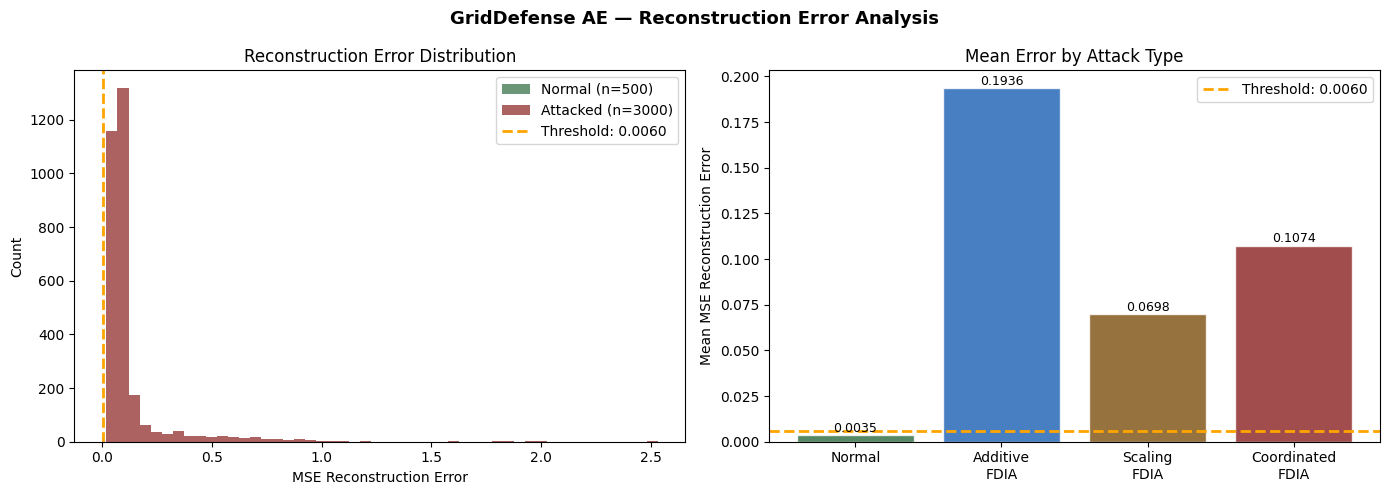


Detection threshold set at: 0.006013
(mean + 2σ of normal reconstruction errors)

Per attack type mean errors:
  Normal      : 0.003502
  Additive    : 0.193616
  Scaling     : 0.069757
  Coordinated : 0.107360


In [ ]:
# GridDefense | AE — Step 4: Test Detection
# Does the AE catch attacked data?
# High reconstruction error on attacked = working correctly

import numpy as np
import matplotlib.pyplot as plt

# Get reconstruction errors
normal_pred    = autoencoder.predict(X_test_normal, verbose=0)
attacked_pred  = autoencoder.predict(attacked_scaled, verbose=0)

# Calculate MSE per sample
normal_errors   = np.mean(np.power(X_test_normal - normal_pred, 2), axis=1)
attacked_errors = np.mean(np.power(attacked_scaled - attacked_pred, 2), axis=1)

print("=" * 55)
print("AE Reconstruction Error — Normal vs Attacked")
print("=" * 55)
print()
print(f"Normal data:")
print(f"  Mean error  : {normal_errors.mean():.6f}")
print(f"  Max error   : {normal_errors.max():.6f}")
print(f"  Std error   : {normal_errors.std():.6f}")
print()
print(f"Attacked data:")
print(f"  Mean error  : {attacked_errors.mean():.6f}")
print(f"  Max error   : {attacked_errors.max():.6f}")
print(f"  Std error   : {attacked_errors.std():.6f}")
print()

# The gap between normal and attacked is what matters
gap = attacked_errors.mean() - normal_errors.mean()
ratio = attacked_errors.mean() / normal_errors.mean()
print(f"Gap (attacked - normal) : {gap:.6f}")
print(f"Ratio (attacked/normal) : {ratio:.2f}x")
print()

if ratio > 1.5:
    print("✓ AE is detecting attacks — clear gap between normal and attacked")
elif ratio > 1.1:
    print("⚠ Weak detection — small gap, needs improvement")
else:
    print("✗ AE not detecting attacks — no meaningful gap")

# ── Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GridDefense AE — Reconstruction Error Analysis',
             fontsize=13, fontweight='bold')

# Plot 1 — Distribution comparison
ax1 = axes[0]
ax1.hist(normal_errors, bins=50, alpha=0.7,
         color='#2d6a3f', label=f'Normal (n={len(normal_errors)})')
ax1.hist(attacked_errors, bins=50, alpha=0.7,
         color='#8a2020', label=f'Attacked (n={len(attacked_errors)})')
ax1.set_title('Reconstruction Error Distribution')
ax1.set_xlabel('MSE Reconstruction Error')
ax1.set_ylabel('Count')
ax1.legend()

# Set threshold at mean + 2 std of normal errors
threshold = normal_errors.mean() + 2 * normal_errors.std()
ax1.axvline(x=threshold, color='orange', linestyle='--',
            linewidth=2, label=f'Threshold: {threshold:.4f}')
ax1.legend()

# Plot 2 — Per attack type
ax2 = axes[1]
n_per_type = len(attacked_errors) // 3
add_errors   = attacked_errors[:n_per_type]
scale_errors = attacked_errors[n_per_type:2*n_per_type]
coord_errors = attacked_errors[2*n_per_type:]

categories = ['Normal', 'Additive\nFDIA', 'Scaling\nFDIA', 'Coordinated\nFDIA']
means      = [normal_errors.mean(), add_errors.mean(),
              scale_errors.mean(), coord_errors.mean()]
colors     = ['#2d6a3f', '#1a5fb4', '#7c4f0e', '#8a2020']

bars = ax2.bar(categories, means, color=colors, alpha=0.8, edgecolor='white')
ax2.axhline(y=threshold, color='orange', linestyle='--',
            linewidth=2, label=f'Threshold: {threshold:.4f}')
ax2.set_title('Mean Error by Attack Type')
ax2.set_ylabel('Mean MSE Reconstruction Error')
ax2.legend()

for bar, val in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.0001,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('ae_detection_results.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print(f"Detection threshold set at: {threshold:.6f}")
print(f"(mean + 2σ of normal reconstruction errors)")
print()
print(f"Per attack type mean errors:")
print(f"  Normal      : {normal_errors.mean():.6f}")
print(f"  Additive    : {add_errors.mean():.6f}")
print(f"  Scaling     : {scale_errors.mean():.6f}")
print(f"  Coordinated : {coord_errors.mean():.6f}")

In [ ]:
# GridDefense | AE — Fix: Scale attacked data correctly

# Get raw attacked data from df_full
feature_cols = (
    [f'Vm_{i+1}'         for i in range(14)] +
    [f'Va_{i+1}'         for i in range(14)] +
    [f'Pd_{i+1}'         for i in range(14)] +
    [f'Qd_{i+1}'         for i in range(14)] +
    [f'P_res_{i+1}'      for i in range(14)] +
    [f'Q_res_{i+1}'      for i in range(14)] +
    [f'LineFlow_{i+1}'   for i in range(20)] +
    [f'BusBalance_{i+1}' for i in range(14)]
)

# Pull attacked rows from df_full
attacked_raw = df_full[df_full['Label'] == 1][feature_cols].values
print(f"Raw attacked data shape : {attacked_raw.shape}")
print(f"Raw attacked range      : {attacked_raw.min():.4f} to {attacked_raw.max():.4f}")

# Apply the SAME scaler that was fitted on normal data
attacked_scaled_fixed = scaler.transform(attacked_raw)
print(f"\nFixed attacked data range: {attacked_scaled_fixed.min():.4f} to {attacked_scaled_fixed.max():.4f}")
print()

# Now retest
normal_pred   = autoencoder.predict(X_test_normal, verbose=0)
attacked_pred = autoencoder.predict(attacked_scaled_fixed, verbose=0)

normal_errors  = np.mean(np.power(X_test_normal - normal_pred, 2), axis=1)
attacked_errors = np.mean(np.power(attacked_scaled_fixed - attacked_pred, 2), axis=1)

print("=" * 55)
print("CORRECTED — AE Reconstruction Error")
print("=" * 55)
print(f"\nNormal data:")
print(f"  Mean error : {normal_errors.mean():.6f}")
print(f"  Std error  : {normal_errors.std():.6f}")
print()
print(f"Attacked data:")
print(f"  Mean error : {attacked_errors.mean():.6f}")
print(f"  Std error  : {attacked_errors.std():.6f}")
print()

ratio = attacked_errors.mean() / normal_errors.mean()
print(f"Ratio (attacked/normal): {ratio:.2f}x")
print()

if ratio > 2.0:
    print("✓ AE is detecting attacks")
elif ratio > 1.2:
    print("⚠ Weak detection — small gap")
else:
    print("✗ AE not detecting — no gap")

# Per attack type
n = len(attacked_errors) // 3
print(f"\nPer attack type:")
print(f"  Additive    : {attacked_errors[:n].mean():.6f}")
print(f"  Scaling     : {attacked_errors[n:2*n].mean():.6f}")
print(f"  Coordinated : {attacked_errors[2*n:].mean():.6f}")
print(f"  Normal      : {normal_errors.mean():.6f}")

Raw attacked data shape : (3000, 118)
Raw attacked range      : -276.6023 to 276.5945

Fixed attacked data range: -8.9687 to 10.0364

CORRECTED — AE Reconstruction Error

Normal data:
  Mean error : 0.003502
  Std error  : 0.001255

Attacked data:
  Mean error : 0.123578
  Std error  : 0.164686

Ratio (attacked/normal): 35.29x

✓ AE is detecting attacks

Per attack type:
  Additive    : 0.193616
  Scaling     : 0.069757
  Coordinated : 0.107360
  Normal      : 0.003502


In [ ]:
# Diagnose what's in the attacked data
print("Checking attacked data columns for extreme values...")
print()

attacked_df = df_full[df_full['Label'] == 1][feature_cols]

print("Feature group ranges in attacked data:")
print()

# Vm should be around 0.95-1.10
vm_cols = [f'Vm_{i+1}' for i in range(14)]
print(f"Voltage magnitude (Vm) — should be 0.95-1.10 pu:")
print(f"  Min: {attacked_df[vm_cols].values.min():.4f}")
print(f"  Max: {attacked_df[vm_cols].values.max():.4f}")

# Va should be around -20 to 0 degrees
va_cols = [f'Va_{i+1}' for i in range(14)]
print(f"\nVoltage angle (Va) — should be -20 to 0 degrees:")
print(f"  Min: {attacked_df[va_cols].values.min():.4f}")
print(f"  Max: {attacked_df[va_cols].values.max():.4f}")

# LineFlow — depends on system
lf_cols = [f'LineFlow_{i+1}' for i in range(20)]
print(f"\nLine flows:")
print(f"  Min: {attacked_df[lf_cols].values.min():.4f}")
print(f"  Max: {attacked_df[lf_cols].values.max():.4f}")

# BusBalance
bb_cols = [f'BusBalance_{i+1}' for i in range(14)]
print(f"\nBus balance:")
print(f"  Min: {attacked_df[bb_cols].values.min():.4f}")
print(f"  Max: {attacked_df[bb_cols].values.max():.4f}")

# Compare normal ranges
normal_df = df_full[df_full['Label'] == 0][feature_cols]
print()
print("=" * 40)
print("Normal data ranges for comparison:")
print(f"  Vm:         {normal_df[vm_cols].values.min():.4f} to {normal_df[vm_cols].values.max():.4f}")
print(f"  Va:         {normal_df[va_cols].values.min():.4f} to {normal_df[va_cols].values.max():.4f}")
print(f"  LineFlow:   {normal_df[lf_cols].values.min():.4f} to {normal_df[lf_cols].values.max():.4f}")
print(f"  BusBalance: {normal_df[bb_cols].values.min():.4f} to {normal_df[bb_cols].values.max():.4f}")

Checking attacked data columns for extreme values...

Feature group ranges in attacked data:

Voltage magnitude (Vm) — should be 0.95-1.10 pu:
  Min: 0.9817
  Max: 1.1210

Voltage angle (Va) — should be -20 to 0 degrees:
  Min: -18.3080
  Max: 0.0187

Line flows:
  Min: -105.6429
  Max: 189.7541

Bus balance:
  Min: -276.6023
  Max: 68.0891

Normal data ranges for comparison:
  Vm:         0.9933 to 1.1111
  Va:         -17.8494 to 0.0184
  LineFlow:   -81.6203 to 186.5087
  BusBalance: -272.8491 to 32.6705


In [ ]:
# GridDefense | AE — Clean Rebuild on Core BUS Features Only
# Vm, Va, Pd, Qd — 56 features — what PMU sensors actually report
# LineFlow, BusBalance, P_res → reserved for physics layer

import keras.backend as K
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

K.clear_session()
tf.random.set_seed(42)

# ── Core BUS features only ───────────────────────────────────
core_cols = (
    [f'Vm_{i+1}' for i in range(14)] +
    [f'Va_{i+1}' for i in range(14)] +
    [f'Pd_{i+1}' for i in range(14)] +
    [f'Qd_{i+1}' for i in range(14)]
)  # 56 features

# Pull normal and attacked separately
normal_raw   = df_full[df_full['Label'] == 0][core_cols].values
attacked_raw = df_full[df_full['Label'] == 1][core_cols].values

print(f"Normal raw   : {normal_raw.min():.4f} to {normal_raw.max():.4f}")
print(f"Attacked raw : {attacked_raw.min():.4f} to {attacked_raw.max():.4f}")
print()

# Fit scaler on normal only
scaler_ae = MinMaxScaler()
normal_sc  = scaler_ae.fit_transform(normal_raw)
attacked_sc = scaler_ae.transform(attacked_raw)

print(f"Normal scaled   : {normal_sc.min():.4f} to {normal_sc.max():.4f}")
print(f"Attacked scaled : {attacked_sc.min():.4f} to {attacked_sc.max():.4f}")
print()

# Train/val/test split
X_tr, X_temp = train_test_split(normal_sc, test_size=0.2, random_state=42)
X_v,  X_te_n = train_test_split(X_temp, test_size=0.5,  random_state=42)

print(f"Train  : {X_tr.shape}")
print(f"Val    : {X_v.shape}")
print(f"Test N : {X_te_n.shape}")
print(f"Test A : {attacked_sc.shape}")
print()

# ── Build AE ─────────────────────────────────────────────────
INPUT_DIM    = 56
ENCODING_DIM = 16

inputs  = keras.Input(shape=(INPUT_DIM,))
x       = layers.Dense(64, activation='relu')(inputs)
x       = layers.Dense(32, activation='relu')(x)
encoded = layers.Dense(ENCODING_DIM, activation='relu', name='bottleneck')(x)
x       = layers.Dense(32, activation='relu')(encoded)
x       = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(INPUT_DIM, activation='sigmoid')(x)

autoencoder = keras.Model(inputs, outputs, name='GridDefense_AE_v3')
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

print(f"✓ AE rebuilt — input dim: {INPUT_DIM}, bottleneck: {ENCODING_DIM}")
print()

# ── Train ────────────────────────────────────────────────────
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10,
    restore_best_weights=True, verbose=1
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=5, min_lr=0.000001, verbose=1
)

print("Training on 56 core PMU features...")
print()

history = autoencoder.fit(
    X_tr, X_tr,
    epochs=100,
    batch_size=32,
    validation_data=(X_v, X_v),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print()
print("=" * 50)
print("✓ Training complete!")
print(f"  Epochs         : {len(history.history['loss'])}")
print(f"  Start loss     : {history.history['loss'][0]:.6f}")
print(f"  Final loss     : {history.history['loss'][-1]:.6f}")
print(f"  Best val loss  : {min(history.history['val_loss']):.6f}")

Normal raw   : -17.8494 to 103.6218
Attacked raw : -18.3080 to 113.0419

Normal scaled   : 0.0000 to 1.0000
Attacked scaled : -0.5136 to 1.5000

Train  : (4000, 56)
Val    : (500, 56)
Test N : (500, 56)
Test A : (3000, 56)

✓ AE rebuilt — input dim: 56, bottleneck: 16

Training on 56 core PMU features...

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0190 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0070 - val_loss: 0.0069 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0068 - val_loss: 0.0068 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0067 - val_loss: 0.0066 - learning_rate: 0.0010
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0065 - val_loss: 0.0065 - learning_rate: 0.0010
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0063 - val_loss: 0.0062 - learning_rate: 0.0010
Epoch 7/100
125/125 ━━━━━━━

THRESHOLD — computed from validation set only
Validation mean error : 0.004073
Validation std error  : 0.001553
Threshold (mean+2σ)   : 0.007178

AE Detection Results — 56 Core PMU Features (test set)

Normal   — mean error : 0.003931
Attacked — mean error : 0.134428
Ratio                 : 34.19x

Attacks detected      : 3000/3000 (100.0%)
False positives       : 17/500 (3.4%)

Per attack type (sliced by actual Attack_Type label):
  Additive     : mean=0.134204 | detected=1000/1000 (100.0%)
  Scaling      : mean=0.133252 | detected=1000/1000 (100.0%)
  Coordinated  : mean=0.135827 | detected=1000/1000 (100.0%)



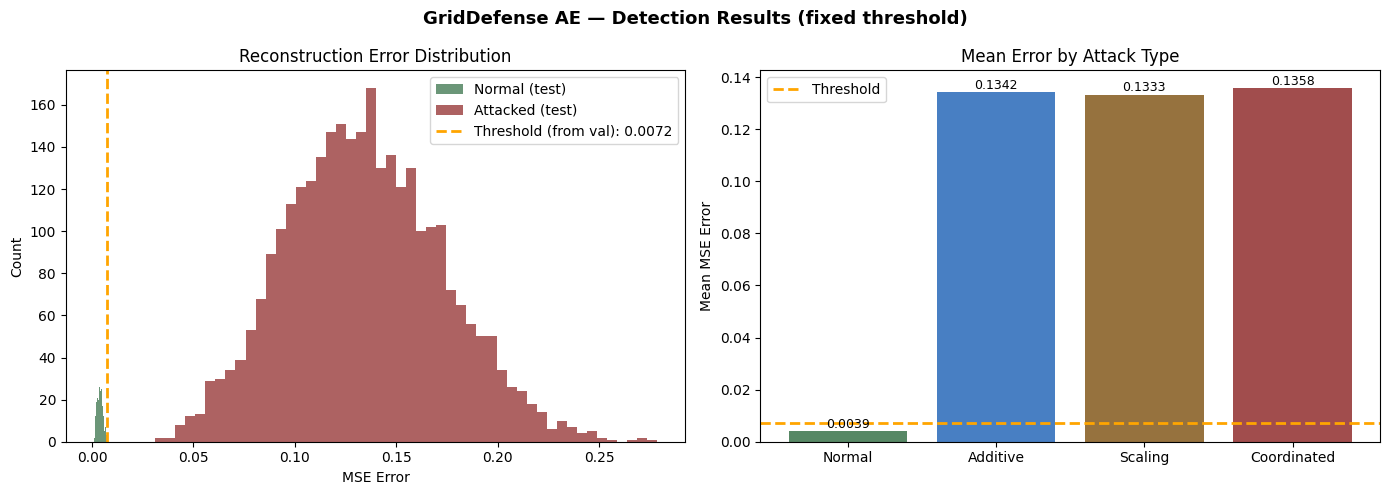

In [ ]:
# ============================================================
# GridDefense | AE — Detection Test on 56 core features
# ============================================================

# ── Step 1: compute threshold from VALIDATION set ────────────
val_pred   = autoencoder.predict(X_v, verbose=0)
val_errors = np.mean(np.power(X_v - val_pred, 2), axis=1)

threshold = val_errors.mean() + 2 * val_errors.std()

print("=" * 55)
print("THRESHOLD — computed from validation set only")
print("=" * 55)
print(f"Validation mean error : {val_errors.mean():.6f}")
print(f"Validation std error  : {val_errors.std():.6f}")
print(f"Threshold (mean+2σ)   : {threshold:.6f}")
print()

# ── Step 2: evaluate on TEST set (untouched until now) ───────
normal_pred   = autoencoder.predict(X_te_n, verbose=0)
attacked_pred = autoencoder.predict(attacked_sc, verbose=0)

normal_errors   = np.mean(np.power(X_te_n - normal_pred, 2), axis=1)
attacked_errors = np.mean(np.power(attacked_sc - attacked_pred, 2), axis=1)

print("=" * 55)
print("AE Detection Results — 56 Core PMU Features (test set)")
print("=" * 55)
print(f"\nNormal   — mean error : {normal_errors.mean():.6f}")
print(f"Attacked — mean error : {attacked_errors.mean():.6f}")
print(f"Ratio                 : {attacked_errors.mean()/normal_errors.mean():.2f}x")
print()

detected  = (attacked_errors > threshold).sum()
false_pos = (normal_errors > threshold).sum()
print(f"Attacks detected      : {detected}/{len(attacked_errors)} "
      f"({detected/len(attacked_errors)*100:.1f}%)")
print(f"False positives       : {false_pos}/{len(normal_errors)} "
      f"({false_pos/len(normal_errors)*100:.1f}%)")
print()

# ── Step 3: per-attack-type breakdown, by ACTUAL label ───────
# Requires that attacked_sc rows still line up 1:1 with the rows
# of df_full[df_full['Label'] == 1] that produced them (same
# order, no shuffling in between). If you ever shuffle attacked
# data before scaling, carry the Attack_Type column alongside it
# through that shuffle too.
attack_type_col = df_full.loc[df_full['Label'] == 1, 'Attack_Type'].values

assert len(attack_type_col) == len(attacked_errors), (
    "Row count mismatch between attack_type_col and attacked_errors — "
    "attacked_sc and df_full's attacked rows are not aligned. "
    "Do not trust the per-type breakdown until this is fixed."
)

print("Per attack type (sliced by actual Attack_Type label):")
for code, name in [(1, "Additive"), (2, "Scaling"), (3, "Coordinated")]:
    mask = attack_type_col == code
    errs = attacked_errors[mask]
    det  = (errs > threshold).sum()
    print(f"  {name:12} : mean={errs.mean():.6f} | "
          f"detected={det}/{len(errs)} ({det/len(errs)*100:.1f}%)")

print()

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GridDefense AE — Detection Results (fixed threshold)',
              fontsize=13, fontweight='bold')

ax1 = axes[0]
ax1.hist(normal_errors,   bins=50, alpha=0.7, color='#2d6a3f', label='Normal (test)')
ax1.hist(attacked_errors, bins=50, alpha=0.7, color='#8a2020', label='Attacked (test)')
ax1.axvline(x=threshold, color='orange', linestyle='--', linewidth=2,
            label=f'Threshold (from val): {threshold:.4f}')
ax1.set_title('Reconstruction Error Distribution')
ax1.set_xlabel('MSE Error')
ax1.set_ylabel('Count')
ax1.legend()

ax2 = axes[1]
categories = ['Normal', 'Additive', 'Scaling', 'Coordinated']
means = [normal_errors.mean()]
for code in [1, 2, 3]:
    means.append(attacked_errors[attack_type_col == code].mean())
colors = ['#2d6a3f', '#1a5fb4', '#7c4f0e', '#8a2020']
bars = ax2.bar(categories, means, color=colors, alpha=0.8)
ax2.axhline(y=threshold, color='orange', linestyle='--', linewidth=2, label='Threshold')
ax2.set_title('Mean Error by Attack Type')
ax2.set_ylabel('Mean MSE Error')
ax2.legend()
for bar, val in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.0001,
              f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Verify which dataset the AE was trained on
print(f"normal_sc shape  : {normal_sc.shape}")
print(f"attacked_sc shape: {attacked_sc.shape}")

# Check if load variation is per-bus (14 different values per row)
# vs global (all 14 buses same value)
sample_Pd = df_full[df_full['Label']==0][[f'Pd_{i+1}' for i in range(14)]].values[:3]
print(f"\nFirst 3 normal samples Pd values:")
print(f"Same across buses? {np.all(sample_Pd[0] == sample_Pd[0][0])}")
print(sample_Pd)

normal_sc shape  : (5000, 56)
attacked_sc shape: (3000, 56)

First 3 normal samples Pd values:
Same across buses? False
[[-2.66824402e-03  2.11554765e+01  9.18351886e+01  4.66025503e+01
   7.40297539e+00  1.09244298e+01  1.38915652e-02  5.96819862e-03
   2.87608799e+01  8.77858102e+00  3.40713266e+00  5.93902247e+00
   1.31651268e+01  1.45234388e+01]
 [-3.51026547e-03  2.09396573e+01  9.09044932e+01  4.61214350e+01
   7.33575925e+00  1.08097159e+01  2.55672832e-05 -1.17293567e-03
   2.84615047e+01  8.68322675e+00  3.37591475e+00  5.88271227e+00
   1.30271885e+01  1.43810666e+01]
 [-7.20020724e-03  2.05673006e+01  8.92635883e+01  4.52874792e+01
   7.20429727e+00  1.06183935e+01  1.13144135e-03  4.23700716e-03
   2.79529357e+01  8.52166330e+00  3.32159302e+00  5.78654333e+00
   1.27952939e+01  1.41133874e+01]]


In [ ]:
# GridDefense | AE — Save trained model

# Save model
autoencoder.save('/content/drive/MyDrive/GridDefense/models/ae_model.keras')

# Save scaler
import pickle
with open('/content/drive/MyDrive/GridDefense/models/scaler_ae.pkl', 'wb') as f:
    pickle.dump(scaler_ae, f)

# Save results
np.save('/content/drive/MyDrive/GridDefense/data/normal_errors.npy', normal_errors)
np.save('/content/drive/MyDrive/GridDefense/data/attacked_errors.npy', attacked_errors)

In [ ]:
# ============================================================
# GridDefense — Chronological Split + 40-Step Sliding Windows
# ============================================================

from sklearn.preprocessing import MinMaxScaler

WINDOW_SIZE = 40
STEP = 1
FILTER_BOUNDARY_WINDOWS = True   # set False to reproduce old (unsafe) behavior

# ------------------------------------------------------------
# 1. Select the 118 bus-level features
# ------------------------------------------------------------
feature_cols = (
    [f'Vm_{i+1}'         for i in range(14)] +
    [f'Va_{i+1}'         for i in range(14)] +
    [f'Pd_{i+1}'         for i in range(14)] +
    [f'Qd_{i+1}'         for i in range(14)] +
    [f'P_res_{i+1}'      for i in range(14)] +
    [f'Q_res_{i+1}'      for i in range(14)] +
    [f'LineFlow_{i+1}'   for i in range(20)] +
    [f'BusBalance_{i+1}' for i in range(14)]
)

features    = df_full[feature_cols].values.astype(np.float32)
labels      = df_full['Label'].values.astype(np.int64)
attack_type = df_full['Attack_Type'].fillna(0).astype(np.int64).values

# ------------------------------------------------------------
# 2. Chronologically split the RAW rows first
# ------------------------------------------------------------
n_total = len(df_full)
train_raw_end = int(n_total * 0.70)
val_raw_end   = int(n_total * 0.85)

X_raw_train, y_raw_train, t_raw_train = (
    features[:train_raw_end], labels[:train_raw_end], attack_type[:train_raw_end]
)
X_raw_val, y_raw_val, t_raw_val = (
    features[train_raw_end:val_raw_end], labels[train_raw_end:val_raw_end],
    attack_type[train_raw_end:val_raw_end]
)
X_raw_test, y_raw_test, t_raw_test = (
    features[val_raw_end:], labels[val_raw_end:], attack_type[val_raw_end:]
)

# ------------------------------------------------------------
# 3. Fit scaler on TRAIN raw rows only, apply to all splits
# ------------------------------------------------------------
scaler_window = MinMaxScaler()
X_raw_train = scaler_window.fit_transform(X_raw_train).astype(np.float32)
X_raw_val   = scaler_window.transform(X_raw_val).astype(np.float32)
X_raw_test  = scaler_window.transform(X_raw_test).astype(np.float32)

print("✓ Scaler fit on training rows only, applied to val/test")

# ------------------------------------------------------------
# 4. Function to create 40-step windows (with optional
#    boundary-contamination filter)
# ------------------------------------------------------------
def create_windows(features, labels, attack_type,
                    window_size=40, step=1, filter_boundaries=True):

    n_windows = (len(features) - window_size) // step + 1

    X_list, y_list = [], []
    dropped = 0

    for i in range(n_windows):
        start = i * step
        end   = start + window_size

        window_labels = labels[start:end]
        window_types  = attack_type[start:end]

        if filter_boundaries:
            # Require ALL rows in the window to share the same
            # Label and Attack_Type, not just the first and last.
            # (For the current contiguous-block data layout, checking
            # first/last only happens to give the same result, since
            # a block can't have another class interleaved inside it —
            # but checking every row removes that hidden assumption,
            # so this stays correct even if the data layout changes.)
            if (not np.all(window_labels == window_labels[0]) or
                    not np.all(window_types == window_types[0])):
                dropped += 1
                continue

        X_list.append(features[start:end])
        y_list.append(window_labels[-1])  # label = last timestep in window

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int64)

    return X, y, dropped

# ------------------------------------------------------------
# 5. Create windows separately inside each split
# ------------------------------------------------------------
X_train, y_train, dropped_train = create_windows(
    X_raw_train, y_raw_train, t_raw_train,
    WINDOW_SIZE, STEP, FILTER_BOUNDARY_WINDOWS
)
X_val, y_val, dropped_val = create_windows(
    X_raw_val, y_raw_val, t_raw_val,
    WINDOW_SIZE, STEP, FILTER_BOUNDARY_WINDOWS
)
X_test, y_test, dropped_test = create_windows(
    X_raw_test, y_raw_test, t_raw_test,
    WINDOW_SIZE, STEP, FILTER_BOUNDARY_WINDOWS
)

# ------------------------------------------------------------
# 6. Check the results
# ------------------------------------------------------------
print("=== GridDefense Sliding Window Results ===")

print("\nWindow configuration:")
print("Window size:", WINDOW_SIZE)
print("Step:", STEP)
print("Boundary filter:", FILTER_BOUNDARY_WINDOWS)
print("Features per timestep:", len(feature_cols))

print("\nTrain:", X_train.shape, "| Labels:", y_train.shape,
      f"| dropped (boundary): {dropped_train}")
print("Val:  ", X_val.shape,   "| Labels:", y_val.shape,
      f"| dropped (boundary): {dropped_val}")
print("Test: ", X_test.shape,  "| Labels:", y_test.shape,
      f"| dropped (boundary): {dropped_test}")

print("\nTotal windows:", len(X_train) + len(X_val) + len(X_test))
print("Total dropped at class boundaries:",
      dropped_train + dropped_val + dropped_test)

✓ Scaler fit on training rows only, applied to val/test
=== GridDefense Sliding Window Results ===

Window configuration:
Window size: 40
Step: 1
Boundary filter: True
Features per timestep: 118

Train: (5522, 40, 118) | Labels: (5522,) | dropped (boundary): 39
Val:   (1122, 40, 118) | Labels: (1122,) | dropped (boundary): 39
Test:  (1122, 40, 118) | Labels: (1122,) | dropped (boundary): 39

Total windows: 7766
Total dropped at class boundaries: 117


In [ ]:
print("Train labels:", np.unique(y_train, return_counts=True))
print("Val labels:  ", np.unique(y_val, return_counts=True))
print("Test labels: ", np.unique(y_test, return_counts=True))
print("\nTrain attack types:")
print(np.unique(t_raw_train, return_counts=True))
print("\nVal attack types:")
print(np.unique(t_raw_val, return_counts=True))

print("\nTest attack types:")
print(np.unique(t_raw_test, return_counts=True))

Train labels: (array([0, 1]), array([4961,  561]))
Val labels:   (array([1]), array([1122]))
Test labels:  (array([1]), array([1122]))

Train attack types:
(array([0, 1]), array([5000,  600]))

Val attack types:
(array([1, 2]), array([400, 800]))

Test attack types:
(array([2, 3]), array([ 200, 1000]))


In [ ]:
# Check for overlap between Train / Validation / Test windows

WINDOW_SIZE = 40
STEP = 1

# Each split starts from a different raw-data boundary.
# We calculate the raw timestep range covered by each split.

train_raw_end = int(len(df_full) * 0.70)
val_raw_end = int(len(df_full) * 0.85)

print("=== Cross-Split Overlap Check ===\n")

print(f"TRAIN:")
print(f"  Raw data: t1 → t{train_raw_end}")
print(f"  Windows: {X_train.shape[0]}")

print(f"\nVALIDATION:")
print(f"  Raw data: t{train_raw_end + 1} → t{val_raw_end}")
print(f"  Windows: {X_val.shape[0]}")

print(f"\nTEST:")
print(f"  Raw data: t{val_raw_end + 1} → t{len(df_full)}")
print(f"  Windows: {X_test.shape[0]}")

# Check the actual boundaries
train_last_end = train_raw_end
val_first_start = train_raw_end + 1

val_last_end = val_raw_end
test_first_start = val_raw_end + 1

print("\n=== Boundary Check ===")

print(f"\nTrain last timestep:       t{train_last_end}")
print(f"Validation first timestep: t{val_first_start}")

print(f"\nValidation last timestep:  t{val_last_end}")
print(f"Test first timestep:       t{test_first_start}")

# Final verdict
if val_first_start > train_last_end and test_first_start > val_last_end:
    print("\n NO CROSS-SPLIT TIMESTAMP OVERLAP")
else:
    print("\n OVERLAP DETECTED")

=== Cross-Split Overlap Check ===

TRAIN:
  Raw data: t1 → t5600
  Windows: 5522

VALIDATION:
  Raw data: t5601 → t6800
  Windows: 1122

TEST:
  Raw data: t6801 → t8000
  Windows: 1122

=== Boundary Check ===

Train last timestep:       t5600
Validation first timestep: t5601

Validation last timestep:  t6800
Test first timestep:       t6801

 NO CROSS-SPLIT TIMESTAMP OVERLAP


In [ ]:
print("Normal shape:", df_normal.shape)
print("Attack shape:", df_attacked.shape)

print("\nColumns in NORMAL but not ATTACK:")
print(df_normal.columns.difference(df_attacked.columns).tolist())

print("\nColumns in ATTACK but not NORMAL:")
print(df_attacked.columns.difference(df_normal.columns).tolist())

print("\nColumns in same set but different ORDER:")
print(df_normal.columns.tolist() == df_attacked.columns.tolist())

Normal shape: (5000, 134)
Attack shape: (3000, 134)

Columns in NORMAL but not ATTACK:
[]

Columns in ATTACK but not NORMAL:
[]

Columns in same set but different ORDER:
True


In [ ]:
print("Normal:", df_normal.shape)
print("Attack:", df_attacked.shape)

print("Columns aligned:",
      df_normal.columns.tolist() == df_attacked.columns.tolist())

print("Missing normal values:", df_normal.isna().sum().sum())
print("Missing attack values:", df_attacked.isna().sum().sum())

Normal: (5000, 134)
Attack: (3000, 134)
Columns aligned: True
Missing normal values: 0
Missing attack values: 0


In [ ]:
# Align attack columns to exactly the same order as normal
df_attacked = df_attacked[df_normal.columns]

# Verify
print("Normal:", df_normal.shape)
print("Attack:", df_attacked.shape)
print("Columns aligned:", df_normal.columns.tolist() == df_attacked.columns.tolist())

Normal: (5000, 134)
Attack: (3000, 134)
Columns aligned: True


In [ ]:
# ============================================================
# Reload df_full from Drive
# ============================================================
import pandas as pd
import numpy as np

df_full = pd.read_csv(
    '/content/drive/MyDrive/GridDefense/data/griddefense_dataset_final.csv'
)

print(f"✓ df_full reloaded: {df_full.shape}")
print(f"  Normal   : {(df_full['Label']==0).sum()}")
print(f"  Attacked : {(df_full['Label']==1).sum()}")
print(f"  Columns  : {df_full.shape[1]}")

✓ df_full reloaded: (8000, 134)
  Normal   : 5000
  Attacked : 3000
  Columns  : 134


In [ ]:
print("df_full shape:", df_full.shape)

print("\nColumns:")
print(df_full.columns.tolist())

print("\nAttack_Type:")
print(df_full['Attack_Type'].value_counts(dropna=False))

print("\nNode feature columns:")
print(node_feature_cols)

print("\nNumber of node features:", len(node_feature_cols))

df_full shape: (8000, 134)

Columns:
['Vm_1', 'Vm_2', 'Vm_3', 'Vm_4', 'Vm_5', 'Vm_6', 'Vm_7', 'Vm_8', 'Vm_9', 'Vm_10', 'Vm_11', 'Vm_12', 'Vm_13', 'Vm_14', 'Va_1', 'Va_2', 'Va_3', 'Va_4', 'Va_5', 'Va_6', 'Va_7', 'Va_8', 'Va_9', 'Va_10', 'Va_11', 'Va_12', 'Va_13', 'Va_14', 'Pd_1', 'Pd_2', 'Pd_3', 'Pd_4', 'Pd_5', 'Pd_6', 'Pd_7', 'Pd_8', 'Pd_9', 'Pd_10', 'Pd_11', 'Pd_12', 'Pd_13', 'Pd_14', 'Qd_1', 'Qd_2', 'Qd_3', 'Qd_4', 'Qd_5', 'Qd_6', 'Qd_7', 'Qd_8', 'Qd_9', 'Qd_10', 'Qd_11', 'Qd_12', 'Qd_13', 'Qd_14', 'bus_label_1', 'bus_label_2', 'bus_label_3', 'bus_label_4', 'bus_label_5', 'bus_label_6', 'bus_label_7', 'bus_label_8', 'bus_label_9', 'bus_label_10', 'bus_label_11', 'bus_label_12', 'bus_label_13', 'bus_label_14', 'Attack_Type', 'Label', 'P_res_1', 'Q_res_1', 'P_res_2', 'Q_res_2', 'P_res_3', 'Q_res_3', 'P_res_4', 'Q_res_4', 'P_res_5', 'Q_res_5', 'P_res_6', 'Q_res_6', 'P_res_7', 'Q_res_7', 'P_res_8', 'Q_res_8', 'P_res_9', 'Q_res_9', 'P_res_10', 'Q_res_10', 'P_res_11', 'Q_res_11', 'P_res_12

In [ ]:
physics_cols = [
    c for c in df_full.columns
    if c.startswith(('P_res_', 'Q_res_', 'BusBalance_'))
]

normal_phys = df_full[df_full['Attack_Type'] == 0][physics_cols]
attack_phys = df_full[df_full['Attack_Type'] != 0][physics_cols]

print("Normal physics mean:", normal_phys.abs().mean().mean())
print("Attack physics mean:", attack_phys.abs().mean().mean())

print("\nNormal physics max:", normal_phys.abs().max().max())
print("Attack physics max:", attack_phys.abs().max().max())

Normal physics mean: 23.007890715629078
Attack physics mean: 24.327810123611254

Normal physics max: 272.84961226862816
Attack physics max: 276.60228098727634


In [ ]:
for col in physics_cols:
    normal_mean = df_full.loc[df_full['Attack_Type'] == 0, col].abs().mean()
    attack_mean = df_full.loc[df_full['Attack_Type'] != 0, col].abs().mean()

    print(
        f"{col:20s} | "
        f"Normal: {normal_mean:.4f} | "
        f"Attack: {attack_mean:.4f} | "
        f"Ratio: {attack_mean / (normal_mean + 1e-9):.2f}"
    )

P_res_1              | Normal: 232.3121 | Attack: 232.3208 | Ratio: 1.00
Q_res_1              | Normal: 17.9100 | Attack: 19.3405 | Ratio: 1.08
P_res_2              | Normal: 18.3306 | Attack: 18.7119 | Ratio: 1.02
Q_res_2              | Normal: 31.7247 | Attack: 34.1681 | Ratio: 1.08
P_res_3              | Normal: 94.1865 | Attack: 94.0215 | Ratio: 1.00
Q_res_3              | Normal: 7.3387 | Attack: 8.7773 | Ratio: 1.20
P_res_4              | Normal: 47.5945 | Attack: 47.5667 | Ratio: 1.00
Q_res_4              | Normal: 18.5277 | Attack: 24.4355 | Ratio: 1.32
P_res_5              | Normal: 8.2298 | Attack: 10.0492 | Ratio: 1.22
Q_res_5              | Normal: 17.1987 | Attack: 22.1202 | Ratio: 1.29
P_res_6              | Normal: 11.2350 | Attack: 11.7909 | Ratio: 1.05
Q_res_6              | Normal: 9.6633 | Attack: 12.4490 | Ratio: 1.29
P_res_7              | Normal: 0.2382 | Attack: 1.2504 | Ratio: 5.25
Q_res_7              | Normal: 9.7733 | Attack: 13.1800 | Ratio: 1.35
P_res_8    

In [15]:
# ============================================================
# GridDefense | GNN — FULL CONSOLIDATED SCRIPT
# ============================================================

!pip install torch-geometric

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, f1_score
from collections import Counter

print("✓ All GNN libraries imported")

# ============================================================
# 1. IEEE 14-bus edge structure
# ============================================================
edges = [
    (0,1),(0,4),(1,2),(1,3),(1,4),
    (2,3),(3,4),(3,6),(3,8),(4,5),
    (5,10),(5,11),(5,12),(6,7),(6,8),
    (8,9),(8,13),(9,10),(11,12),(12,13)
]

impedances = [
    0.05917,0.22304,0.19797,0.17632,0.17388,
    0.17103,0.04211,0.20912,0.55618,0.25202,
    0.19890,0.25581,0.13027,0.17615,0.11001,
    0.84573,0.27038,0.19207,0.19988,0.34802
]

src, dst, ew = [], [], []
for idx, (i, j) in enumerate(edges):
    src += [i, j]
    dst += [j, i]
    ew  += [impedances[idx], impedances[idx]]

EDGE_INDEX = torch.tensor([src, dst], dtype=torch.long)
EDGE_ATTR  = torch.tensor([[w] for w in ew], dtype=torch.float)

print(f"✓ Edge index shape: {EDGE_INDEX.shape}")
print(f"✓ Edge attr shape : {EDGE_ATTR.shape}")

# ============================================================
# 2. Node feature columns (7 per bus × 14 buses = 98)
# ============================================================
BUS_FEATURE_GROUPS = ['Vm', 'Va', 'Pd', 'Qd', 'P_res', 'Q_res', 'BusBalance']

def get_node_feature_cols():
    cols = []
    for g in BUS_FEATURE_GROUPS:
        for b in range(1, 15):
            cols.append(f'{g}_{b}')
    return cols

node_feature_cols = get_node_feature_cols()
print(f"✓ Node feature columns: {len(node_feature_cols)} "
      f"({len(BUS_FEATURE_GROUPS)} features × 14 buses)")

# ============================================================
# 3. build_graph — one PyG Data object per sample row
# ============================================================
def build_graph(row, edge_index, edge_attr):
    node_feats = []
    for b in range(1, 15):
        feats = [row[f'{g}_{b}'] for g in BUS_FEATURE_GROUPS]
        node_feats.append(feats)

    x = torch.tensor(node_feats, dtype=torch.float)  # [14, 7]

    y_node = torch.tensor(
        [row[f'bus_label_{b}'] for b in range(1, 15)],
        dtype=torch.float
    )  # [14]

    y_sample = torch.tensor(int(row['Attack_Type']), dtype=torch.long)

    return Data(
        x=x, edge_index=edge_index, edge_attr=edge_attr,
        y_node=y_node, y_sample=y_sample
    )

# ============================================================
# 4. Stratified split (by Attack_Type) — fixes the earlier
#    positional split, which put whole classes only in train
# ============================================================
print("\n" + "=" * 65)
print("STRATIFIED SPLIT")
print("=" * 65)

all_indices = list(range(len(df_full)))
all_labels  = df_full['Attack_Type'].fillna(0).astype(int).tolist()

train_idx, temp_idx = train_test_split(
    all_indices, test_size=0.30, random_state=42, stratify=all_labels
)
temp_labels = [all_labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=42, stratify=temp_labels
)

assert len(set(train_idx) & set(val_idx)) == 0
assert len(set(train_idx) & set(test_idx)) == 0
assert len(set(val_idx) & set(test_idx)) == 0
print("✓ No index overlap")

print(f"\nSplit sizes: Train={len(train_idx)}  Val={len(val_idx)}  Test={len(test_idx)}")
print("Class distribution:")
print("  Train:", Counter(all_labels[i] for i in train_idx))
print("  Val:  ", Counter(all_labels[i] for i in val_idx))
print("  Test: ", Counter(all_labels[i] for i in test_idx))

# ============================================================
# 5. Fit scaler on TRAINING rows only
# ============================================================
scaler_final = MinMaxScaler()
scaler_final.fit(df_full.iloc[train_idx][node_feature_cols])
print("\n✓ Scaler fitted ONLY on training data")

df_scaled_final = df_full.copy()
df_scaled_final[node_feature_cols] = scaler_final.transform(
    df_full[node_feature_cols]
)

# ============================================================
# 6. Build graphs for every row
# ============================================================
print("\nBuilding graphs...")
dataset_final = []
for idx, row in df_scaled_final.iterrows():
    dataset_final.append(build_graph(row, EDGE_INDEX, EDGE_ATTR))
print(f"✓ {len(dataset_final)} graphs created")

train_data_final = [dataset_final[i] for i in train_idx]
val_data_final   = [dataset_final[i] for i in val_idx]
test_data_final  = [dataset_final[i] for i in test_idx]

train_loader_final = PyGDataLoader(train_data_final, batch_size=32, shuffle=True)
val_loader_final   = PyGDataLoader(val_data_final,   batch_size=32, shuffle=False)
test_loader_final  = PyGDataLoader(test_data_final,  batch_size=32, shuffle=False)

print(f"\n✓ Loaders created — Train:{len(train_data_final)}  "
      f"Val:{len(val_data_final)}  Test:{len(test_data_final)}")

# ============================================================
# 7. Model — consistent forward() signature everywhere,
#    edge weights actually used
# ============================================================
class GridDefenseGNN_v2(nn.Module):
    def __init__(self, in_channels=7, hidden_channels=32,
                 num_classes=4, dropout=0.4):
        super().__init__()
        self.dropout = dropout

        self.conv1 = GCNConv(in_channels,     hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)

        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.bn3 = nn.BatchNorm1d(hidden_channels)

        self.node_head = nn.Sequential(
            nn.Linear(hidden_channels, 32), nn.ReLU(), nn.Linear(32, 1)
        )
        self.sample_head = nn.Sequential(
            nn.Linear(hidden_channels, 32), nn.ReLU(), nn.Linear(32, num_classes)
        )

    def forward(self, x, edge_index, batch, edge_weight=None):
        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_weight=edge_weight)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn2(self.conv2(x, edge_index, edge_weight=edge_weight)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn3(self.conv3(x, edge_index, edge_weight=edge_weight)))

        node_logits = self.node_head(x).squeeze(-1)
        x_graph       = global_mean_pool(x, batch)
        sample_logits = self.sample_head(x_graph)
        return node_logits, sample_logits


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_final = GridDefenseGNN_v2(
    in_channels=7, hidden_channels=32, num_classes=4, dropout=0.4
).to(device)

# pos_weight addresses class imbalance in node-level labels: only a
# small fraction of bus-instances are actually attacked, so without
# this the model can get away with mostly predicting "not attacked"
# and still look fine on macro accuracy. Computed from the TRAINING
# set only, so it doesn't leak test-set information.
train_node_labels = np.array([g.y_node.numpy() for g in train_data_final]).flatten()
pos_ratio  = train_node_labels.mean()               # fraction of positives
pos_weight = torch.tensor([5.0]).to(device)
print(f"Node-level pos_weight: {pos_weight.item():.3f} "
      f"(train positive rate: {pos_ratio*100:.2f}%)")

criterion_node   = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
criterion_sample = nn.CrossEntropyLoss()
optimizer_final  = torch.optim.Adam(model_final.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_final  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_final, factor=0.5, patience=5)

print(f"\n✓ Fresh GNN created — device: {device}")

def run_model(model, batch):
    edge_weight = batch.edge_attr.squeeze() if batch.edge_attr is not None else None
    return model(batch.x, batch.edge_index, batch.batch, edge_weight=edge_weight)

# ============================================================
# 8. Training loop
# ============================================================
EPOCHS = 80
best_val_loss = float('inf')
best_state = None

print("\n" + "=" * 65)
print("TRAINING")
print("=" * 65)

for epoch in range(1, EPOCHS + 1):
    model_final.train()
    train_loss = 0.0
    for batch in train_loader_final:
        batch = batch.to(device)
        optimizer_final.zero_grad()
        node_logits, sample_logits = run_model(model_final, batch)
        loss_node   = criterion_node(node_logits, batch.y_node)
        loss_sample = criterion_sample(sample_logits, batch.y_sample)
        loss = loss_node + loss_sample
        loss.backward()
        optimizer_final.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_final)

    model_final.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader_final:
            batch = batch.to(device)
            node_logits, sample_logits = run_model(model_final, batch)
            loss_node   = criterion_node(node_logits, batch.y_node)
            loss_sample = criterion_sample(sample_logits, batch.y_sample)
            val_loss += (loss_node + loss_sample).item()
    val_loss /= len(val_loader_final)
    scheduler_final.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model_final.state_dict().items()}

    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS} | Train: {train_loss:.4f} | "
              f"Val: {val_loss:.4f} | Best: {best_val_loss:.4f}")

model_final.load_state_dict(best_state)
print("\n✓ Training complete")
print(f"✓ Best validation loss: {best_val_loss:.4f}")

# ============================================================
# 9. Final test — never used for training or model selection
# ============================================================
model_final.eval()
all_node_pred, all_node_true = [], []
all_sample_pred, all_sample_true = [], []

with torch.no_grad():
    for batch in test_loader_final:
        batch = batch.to(device)
        node_logits, sample_logits = run_model(model_final, batch)
        node_preds   = (torch.sigmoid(node_logits) > 0.5).long()
        sample_preds = sample_logits.argmax(dim=1)

        all_node_pred.append(node_preds.cpu().numpy())
        all_node_true.append(batch.y_node.long().cpu().numpy())
        all_sample_pred.append(sample_preds.cpu().numpy())
        all_sample_true.append(batch.y_sample.cpu().numpy())

node_pred   = np.concatenate(all_node_pred)
node_true   = np.concatenate(all_node_true)
sample_pred = np.concatenate(all_sample_pred)
sample_true = np.concatenate(all_sample_true)

print("\n" + "=" * 65)
print("FINAL GNN TEST RESULTS")
print("=" * 65)

node_acc = accuracy_score(node_true, node_pred)
node_f1  = f1_score(node_true, node_pred, average='macro')
print("\nNode-Level Detection")
print(f"  Accuracy : {node_acc * 100:.2f}%")
print(f"  Macro F1 : {node_f1:.4f}")

# Per-bus accuracy — which specific buses are hardest to detect
node_pred_2d = node_pred.reshape(-1, 14)
node_true_2d = node_true.reshape(-1, 14)
print("\nPer-bus detection accuracy:")
for b in range(14):
    acc = accuracy_score(node_true_2d[:, b], node_pred_2d[:, b])
    print(f"  Bus {b+1:2d}: {acc*100:.2f}%")

sample_acc = accuracy_score(sample_true, sample_pred)
print("\nSample-Level Attack Classification")
print(f"  Accuracy : {sample_acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(
    sample_true, sample_pred,
    target_names=['Normal', 'Additive', 'Scaling', 'Coordinated'],
    zero_division=0
))

# ============================================================
# 10. Save
# ============================================================
import os
os.makedirs('/content/drive/MyDrive/GridDefense/models', exist_ok=True)
torch.save(model_final.state_dict(), '/content/drive/MyDrive/GridDefense/models/gnn_final.pt')
torch.save(EDGE_INDEX, '/content/drive/MyDrive/GridDefense/models/edge_index.pt')
print("\n✓ Final model + edge index saved to Drive")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 820.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 6.8 MB/s eta 0:00:00
✓ All GNN libraries imported
✓ Edge index shape: torch.Size([2, 40])
✓ Edge attr shape : torch.Size([40, 1])
✓ Node feature columns: 98 (7 features × 14 buses)

STRATIFIED SPLIT
✓ No index overlap

Split sizes: Train=5600  Val=1200  Test=1200
Class distribution:
  Train: Counter({0: 3500, 1: 700, 3: 700, 2: 700})
  Val:   Counter({0: 750, 2: 150, 1: 150, 3: 150})
  Test:  Counter({0: 750, 2: 150, 3: 150, 1: 150})

✓ Scaler fitted ONLY on training data

Building graphs...
✓ 8000 graphs created

✓ Loaders created — Train:5600  Val:1200  Test:1200
Node-level pos_weight: 5.000 (train positive rate: 5.84%)

✓ Fresh GNN created — device: cpu

TRAINING
Epoch   1/80 | Train: 1.5061 | Val: 0.9640 | Best: 0.9640
Epoch  10/80 | Train: 0.8332 | Val: 0.7632 | Best: 0.7632
Epoch  20/80 | Train: 0.8013 | Val: 0.7433 | Best: 0.7414
Epoch  30/80 | 

In [ ]:
# ============================================================
# GridDefense | Random Forest Baseline — vs GNN
#
# Uses the EXACT same 98 features (node_feature_cols: Vm, Va, Pd,
# Qd, P_res, Q_res, BusBalance x 14 buses) and the EXACT same
# stratified train/val/test split (train_idx/val_idx/test_idx)
# as your GNN run, so this is a fair, apples-to-apples comparison
# — not a different feature set, not a different split.
#
# Trains two separate RFs, mirroring the GNN's two heads:
#   1. Sample-level: predict Attack_Type (0/1/2/3) from the
#      flattened 98 features of that sample.
#   2. Node-level: predict, for EACH bus separately, whether that
#      bus is attacked (bus_label_i), using that sample's full 98
#      features as input (a plain classifier doesn't have "graph
#      structure" — it just gets fed everything and has to figure
#      out which bus is off on its own).
# ============================================================

import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

# ============================================================
# 1. Flat feature matrix — same 98 columns GNN uses
# ============================================================
X_all = df_full[node_feature_cols].values
y_sample_all = df_full['Attack_Type'].fillna(0).astype(int).values

# Same scaler discipline: fit on TRAIN rows only
scaler_rf = MinMaxScaler()
scaler_rf.fit(df_full.iloc[train_idx][node_feature_cols])
X_scaled = scaler_rf.transform(X_all)

X_train_rf = X_scaled[train_idx]
X_test_rf  = X_scaled[test_idx]

y_train_sample = y_sample_all[train_idx]
y_test_sample  = y_sample_all[test_idx]

print("=" * 65)
print("RANDOM FOREST BASELINE — same 98 features, same split as GNN")
print("=" * 65)
print(f"Train: {X_train_rf.shape}   Test: {X_test_rf.shape}")

# ============================================================
# 2. Sample-level: attack type classification
# ============================================================
rf_sample = RandomForestClassifier(
    n_estimators=200, max_depth=None, random_state=42, n_jobs=-1
)
rf_sample.fit(X_train_rf, y_train_sample)
pred_sample_rf = rf_sample.predict(X_test_rf)

rf_sample_acc = accuracy_score(y_test_sample, pred_sample_rf)
rf_sample_f1  = f1_score(y_test_sample, pred_sample_rf, average='macro')

print("\n" + "=" * 65)
print("RF — SAMPLE-LEVEL ATTACK-TYPE CLASSIFICATION")
print("=" * 65)
print(f"Accuracy : {rf_sample_acc*100:.2f}%")
print(f"Macro F1 : {rf_sample_f1:.4f}")
print()
print(classification_report(
    y_test_sample, pred_sample_rf,
    target_names=['Normal', 'Additive', 'Scaling', 'Coordinated'],
    zero_division=0
))

# ============================================================
# 3. Node-level: is EACH bus attacked? (14 separate binary RFs)
# ============================================================
bus_label_cols = [f'bus_label_{b}' for b in range(1, 15)]
y_node_all = df_full[bus_label_cols].values  # shape [n_samples, 14]

y_train_node = y_node_all[train_idx]
y_test_node  = y_node_all[test_idx]

all_node_pred_rf = np.zeros_like(y_test_node)

print("\n" + "=" * 65)
print("RF — NODE-LEVEL (per-bus attacked or not), one RF per bus")
print("=" * 65)

for b in range(14):
    rf_bus = RandomForestClassifier(
        n_estimators=200, max_depth=None, random_state=42,
        n_jobs=-1, class_weight='balanced'  # RF's own imbalance handling
    )
    rf_bus.fit(X_train_rf, y_train_node[:, b])
    all_node_pred_rf[:, b] = rf_bus.predict(X_test_rf)

# Flatten to match GNN's node-level reporting shape
node_true_rf = y_test_node.flatten()
node_pred_rf = all_node_pred_rf.flatten()

rf_node_precision = precision_score(node_true_rf, node_pred_rf, zero_division=0)
rf_node_recall    = recall_score(node_true_rf, node_pred_rf, zero_division=0)
rf_node_f1        = f1_score(node_true_rf, node_pred_rf, zero_division=0)

print(f"\nPositive-class (attacked-bus) metrics:")
print(f"  Precision : {rf_node_precision:.4f}")
print(f"  Recall    : {rf_node_recall:.4f}")
print(f"  F1        : {rf_node_f1:.4f}")
print()
print("Confusion matrix (rows=true, cols=predicted; 0=not attacked, 1=attacked):")
print(confusion_matrix(node_true_rf, node_pred_rf))

# ============================================================
# 4. Head-to-head comparison table
# ============================================================
print("\n" + "=" * 65)
print("HEAD-TO-HEAD — RF vs GNN (same features, same split)")
print("=" * 65)
print(f"{'Task':<35}{'RF':>12}{'GNN':>12}")
print("-" * 59)
print(f"{'Sample-level accuracy':<35}{rf_sample_acc*100:>11.2f}%{'82.17%':>12}")
print(f"{'Sample-level macro F1':<35}{rf_sample_f1:>12.4f}{'~0.62':>12}")
print(f"{'Node-level precision (positive)':<35}{rf_node_precision:>12.4f}{'~0.36':>12}")
print(f"{'Node-level recall (positive)':<35}{rf_node_recall:>12.4f}{'~0.68':>12}")
print(f"{'Node-level F1 (positive)':<35}{rf_node_f1:>12.4f}{'~0.47':>12}")
print()
print("Note: GNN numbers above are hardcoded from your latest run for")
print("quick comparison — replace with your exact latest values if they")
print("differ, or compare against the printed full_metrics.py output directly.")

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


RANDOM FOREST BASELINE — same 98 features, same split as GNN
Train: (5600, 98)   Test: (1200, 98)

RF — SAMPLE-LEVEL ATTACK-TYPE CLASSIFICATION
Accuracy : 83.42%
Macro F1 : 0.6576

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       750
    Additive       0.60      0.45      0.51       150
     Scaling       0.55      0.83      0.66       150
 Coordinated       0.54      0.40      0.46       150

    accuracy                           0.83      1200
   macro avg       0.67      0.67      0.66      1200
weighted avg       0.84      0.83      0.83      1200


RF — NODE-LEVEL (per-bus attacked or not), one RF per bus

Positive-class (attacked-bus) metrics:
  Precision : 0.9476
  Recall    : 0.1881
  F1        : 0.3140

Confusion matrix (rows=true, cols=predicted; 0=not attacked, 1=attacked):
[[15828    10]
 [  781   181]]

HEAD-TO-HEAD — RF vs GNN (same features, same split)
Task                                         RF         GNN
--

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

cm_node = confusion_matrix(node_true, node_pred)

print("Node-level confusion matrix:")
print(cm_node)

print("\nTN:", cm_node[0, 0])
print("FP:", cm_node[0, 1])
print("FN:", cm_node[1, 0])
print("TP:", cm_node[1, 1])

print("\nMetrics:")
print(f"Precision: {precision_score(node_true, node_pred):.4f}")
print(f"Recall:    {recall_score(node_true, node_pred):.4f}")
print(f"F1:        {f1_score(node_true, node_pred):.4f}")

tn, fp, fn, tp = cm_node.ravel()
print(f"FPR:       {fp / (fp + tn):.4f}")
print(f"FNR:       {fn / (fn + tp):.4f}")

Node-level confusion matrix:
[[14681  1157]
 [  309   653]]

TN: 14681
FP: 1157
FN: 309
TP: 653

Metrics:
Precision: 0.3608
Recall:    0.6788
F1:        0.4711
FPR:       0.0731
FNR:       0.3212


In [ ]:
# ============================================================
# GridDefense | AE + GNN Combined Evaluation (FIXED)
# ============================================================

print("=" * 60)
print("COMBINED AE + GNN EVALUATION")
print("=" * 60)
print()

# ── Alignment checks ──────────────────────────────────────────
assert len(sample_pred) == len(test_idx), (
    "sample_pred and test_idx have different lengths — they don't "
    "correspond to the same GNN test run. Re-run the GNN eval cell "
    "immediately before this one."
)

test_indices = list(test_idx)  # from GNN's stratified split

core_cols = (
    [f'Vm_{i+1}' for i in range(14)] +
    [f'Va_{i+1}' for i in range(14)] +
    [f'Pd_{i+1}' for i in range(14)] +
    [f'Qd_{i+1}' for i in range(14)]
)

test_df        = df_full.iloc[test_indices].reset_index(drop=True)
test_features  = test_df[core_cols].values
test_labels    = test_df['Label'].values
test_ae_scaled = scaler_ae.transform(test_features)

# ── AE reconstruction errors on the GNN's test rows ───────────
test_pred_ae   = autoencoder.predict(test_ae_scaled, verbose=0)
test_ae_errors = np.mean(np.power(test_ae_scaled - test_pred_ae, 2), axis=1)

# ── AE threshold — computed HERE from validation, not reused ─
val_pred_ae   = autoencoder.predict(X_v, verbose=0)
val_ae_errors = np.mean(np.power(X_v - val_pred_ae, 2), axis=1)
ae_threshold  = val_ae_errors.mean() + 2 * val_ae_errors.std()

ae_flags = test_ae_errors > ae_threshold

# ── GNN predictions on the same test rows ─────────────────────
gnn_flags  = sample_pred != 0   # anything not "normal" class
gnn_attack = sample_pred

print(f"Test set size: {len(test_labels)}")
print(f"AE threshold : {ae_threshold:.6f} (mean + 2σ, from validation)")
print()

# ── Scenario Analysis ─────────────────────────────────────────
both_flag = ae_flags & gnn_flags
only_ae   = ae_flags & ~gnn_flags
only_gnn  = ~ae_flags & gnn_flags
neither   = ~ae_flags & ~gnn_flags

print("=" * 60)
print("SIGNAL AGREEMENT ANALYSIS")
print("=" * 60)
print(f"Both AE + GNN flag    : {both_flag.sum()}")
print(f"Only AE flags         : {only_ae.sum()}")
print(f"Only GNN flags        : {only_gnn.sum()}")
print(f"Neither flags         : {neither.sum()}")
print()

combined_pred = np.where(both_flag, 'HIGH_CONFIDENCE_ATTACK',
                np.where(ae_flags | gnn_flags, 'POSSIBLE_ATTACK',
                'NORMAL'))

# ── Performance metrics ────────────────────────────────────────
true_attacks = test_labels == 1
true_normal  = test_labels == 0

assert true_attacks.sum() > 0 and true_normal.sum() > 0, (
    "Test set is missing an entire class (all attack or all normal) — "
    "check the GNN's stratified split."
)

ae_detects_attacks  = ae_flags[true_attacks].sum()
gnn_detects_attacks = gnn_flags[true_attacks].sum()
both_detect_attacks = both_flag[true_attacks].sum()
either_detects      = (ae_flags | gnn_flags)[true_attacks].sum()

print("=" * 60)
print("DETECTION RATES ON ATTACKED SAMPLES")
print("=" * 60)
print(f"AE alone detects       : {ae_detects_attacks}/{true_attacks.sum()} ({ae_detects_attacks/true_attacks.sum()*100:.1f}%)")
print(f"GNN alone detects      : {gnn_detects_attacks}/{true_attacks.sum()} ({gnn_detects_attacks/true_attacks.sum()*100:.1f}%)")
print(f"BOTH detect (high conf): {both_detect_attacks}/{true_attacks.sum()} ({both_detect_attacks/true_attacks.sum()*100:.1f}%)")
print(f"EITHER detect          : {either_detects}/{true_attacks.sum()} ({either_detects/true_attacks.sum()*100:.1f}%)")
print()

ae_fp   = ae_flags[true_normal].sum()
gnn_fp  = gnn_flags[true_normal].sum()
both_fp = both_flag[true_normal].sum()

print("=" * 60)
print("FALSE POSITIVE RATES ON NORMAL SAMPLES")
print("=" * 60)
print(f"AE false positives     : {ae_fp}/{true_normal.sum()} ({ae_fp/true_normal.sum()*100:.1f}%)")
print(f"GNN false positives    : {gnn_fp}/{true_normal.sum()} ({gnn_fp/true_normal.sum()*100:.1f}%)")
print(f"BOTH false positives   : {both_fp}/{true_normal.sum()} ({both_fp/true_normal.sum()*100:.1f}%)")
print()

print("=" * 60)
print("KEY INSIGHT")
print("=" * 60)
print(f"When BOTH must agree:")
print(f"  Detection rate : {both_detect_attacks/true_attacks.sum()*100:.1f}%")
print(f"  False pos rate : {both_fp/true_normal.sum()*100:.1f}%")
print()
print(f"When EITHER can flag:")
print(f"  Detection rate : {either_detects/true_attacks.sum()*100:.1f}%")
print(f"  False pos rate : {(ae_flags | gnn_flags)[true_normal].sum()/true_normal.sum()*100:.1f}%")
print()

print("=" * 60)
print("SUMMARY TABLE — AE vs GNN vs AE+GNN")
print("=" * 60)
print(f"{'Model':<20} {'Detection':>12} {'FP Rate':>10}")
print("-" * 44)
print(f"{'AE alone':<20} {ae_detects_attacks/true_attacks.sum()*100:>11.1f}% {ae_fp/true_normal.sum()*100:>9.1f}%")
print(f"{'GNN alone':<20} {gnn_detects_attacks/true_attacks.sum()*100:>11.1f}% {gnn_fp/true_normal.sum()*100:>9.1f}%")
print(f"{'AE+GNN (both)':<20} {both_detect_attacks/true_attacks.sum()*100:>11.1f}% {both_fp/true_normal.sum()*100:>9.1f}%")
print(f"{'AE+GNN (either)':<20} {either_detects/true_attacks.sum()*100:>11.1f}% {(ae_flags|gnn_flags)[true_normal].sum()/true_normal.sum()*100:>9.1f}%")

COMBINED AE + GNN EVALUATION

Test set size: 1200
AE threshold : 0.007178 (mean + 2σ, from validation)

SIGNAL AGREEMENT ANALYSIS
Both AE + GNN flag    : 450
Only AE flags         : 20
Only GNN flags        : 0
Neither flags         : 730

DETECTION RATES ON ATTACKED SAMPLES
AE alone detects       : 450/450 (100.0%)
GNN alone detects      : 450/450 (100.0%)
BOTH detect (high conf): 450/450 (100.0%)
EITHER detect          : 450/450 (100.0%)

FALSE POSITIVE RATES ON NORMAL SAMPLES
AE false positives     : 20/750 (2.7%)
GNN false positives    : 0/750 (0.0%)
BOTH false positives   : 0/750 (0.0%)

KEY INSIGHT
When BOTH must agree:
  Detection rate : 100.0%
  False pos rate : 0.0%

When EITHER can flag:
  Detection rate : 100.0%
  False pos rate : 2.7%

SUMMARY TABLE — AE vs GNN vs AE+GNN
Model                   Detection    FP Rate
--------------------------------------------
AE alone                   100.0%       2.7%
GNN alone                  100.0%       0.0%
AE+GNN (both)             

In [ ]:
# ============================================================
# GridDefense | Full Classification Metrics — AE + GNN
# ============================================================

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import numpy as np

# ============================================================
# 1. AE — binary attack-vs-normal metrics
# ============================================================
print("=" * 60)
print("AE — BINARY METRICS (attack vs normal)")
print("=" * 60)

ae_precision = precision_score(test_labels, ae_flags.astype(int))
ae_recall    = recall_score(test_labels, ae_flags.astype(int))
ae_f1        = f1_score(test_labels, ae_flags.astype(int))

print(f"Precision : {ae_precision:.4f}")
print(f"Recall    : {ae_recall:.4f}")
print(f"F1 score  : {ae_f1:.4f}")
print()
print("Confusion matrix (rows=true, cols=predicted; 0=Normal, 1=Attack):")
print(confusion_matrix(test_labels, ae_flags.astype(int)))
print()

# ============================================================
# 2. GNN — binary (attack vs normal, from sample-level output)
# ============================================================
print("=" * 60)
print("GNN — BINARY METRICS (attack vs normal, from sample_pred)")
print("=" * 60)

gnn_binary_true = (sample_true != 0).astype(int)
gnn_binary_pred = (sample_pred != 0).astype(int)

gnn_precision = precision_score(gnn_binary_true, gnn_binary_pred)
gnn_recall    = recall_score(gnn_binary_true, gnn_binary_pred)
gnn_f1        = f1_score(gnn_binary_true, gnn_binary_pred)

print(f"Precision : {gnn_precision:.4f}")
print(f"Recall    : {gnn_recall:.4f}")
print(f"F1 score  : {gnn_f1:.4f}")
print()
print("Confusion matrix (rows=true, cols=predicted; 0=Normal, 1=Attack):")
print(confusion_matrix(gnn_binary_true, gnn_binary_pred))
print()

# ============================================================
# 3. GNN — 4-CLASS attack-type confusion matrix
#    (This is the important one: binary can be 100%/0% while
#    the model still confuses Additive vs Scaling vs Coordinated
#    internally. This shows whether that's happening.)
# ============================================================
print("=" * 60)
print("GNN — 4-CLASS ATTACK-TYPE CONFUSION MATRIX")
print("=" * 60)

class_names = ['Normal', 'Additive', 'Scaling', 'Coordinated']
cm = confusion_matrix(sample_true, sample_pred, labels=[0, 1, 2, 3])

print(f"{'':14}" + "".join(f"{name:>13}" for name in class_names) + "  (predicted →)")
for i, name in enumerate(class_names):
    print(f"{name:14}" + "".join(f"{cm[i][j]:>13}" for j in range(4)))
print()
print("Per-class precision/recall/F1:")
print(classification_report(
    sample_true, sample_pred, target_names=class_names, zero_division=0
))

# ============================================================
# 4. GNN — node-level (which bus is attacked) full metrics
# ============================================================
print("=" * 60)
print("GNN — NODE-LEVEL METRICS (per-bus attack detection)")
print("=" * 60)

node_precision = precision_score(node_true, node_pred, average='macro', zero_division=0)
node_recall    = recall_score(node_true, node_pred, average='macro', zero_division=0)
node_f1        = f1_score(node_true, node_pred, average='macro', zero_division=0)

print(f"Macro Precision : {node_precision:.4f}")
print(f"Macro Recall    : {node_recall:.4f}")
print(f"Macro F1        : {node_f1:.4f}")
print()
print("Overall confusion matrix (rows=true, cols=predicted; 0=not attacked, 1=attacked):")
print(confusion_matrix(node_true, node_pred))

# ============================================================
# 5. Side-by-side summary
# ============================================================
print()
print("=" * 60)
print("SUMMARY — Precision / Recall / F1")
print("=" * 60)
print(f"{'Model':<25}{'Precision':>12}{'Recall':>10}{'F1':>10}")
print("-" * 57)
print(f"{'AE (binary)':<25}{ae_precision:>12.4f}{ae_recall:>10.4f}{ae_f1:>10.4f}")
print(f"{'GNN (binary)':<25}{gnn_precision:>12.4f}{gnn_recall:>10.4f}{gnn_f1:>10.4f}")
print(f"{'GNN (node-level, macro)':<25}{node_precision:>12.4f}{node_recall:>10.4f}{node_f1:>10.4f}")

AE — BINARY METRICS (attack vs normal)
Precision : 0.9574
Recall    : 1.0000
F1 score  : 0.9783

Confusion matrix (rows=true, cols=predicted; 0=Normal, 1=Attack):
[[730  20]
 [  0 450]]

GNN — BINARY METRICS (attack vs normal, from sample_pred)
Precision : 1.0000
Recall    : 1.0000
F1 score  : 1.0000

Confusion matrix (rows=true, cols=predicted; 0=Normal, 1=Attack):
[[750   0]
 [  0 450]]

GNN — 4-CLASS ATTACK-TYPE CONFUSION MATRIX
                     Normal     Additive      Scaling  Coordinated  (predicted →)
Normal                  750            0            0            0
Additive                  0           96           45            9
Scaling                   0           22          117           11
Coordinated               0           62           62           26

Per-class precision/recall/F1:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       750
    Additive       0.53      0.64      0.58       150
     Scaling       

In [ ]:
# ============================================================
# GridDefense | Ablation Test — Physics Features vs Raw Only
#
# Purpose: isolate whether P_res/Q_res/BusBalance are actually
# what's driving the near-perfect detection, or whether raw
# Vm/Va/Pd/Qd alone would do almost as well. This is the single
# most convincing evidence for "why our physics-informed
# features matter" in your writeup.
#
# This reuses the SAME stratified split (train_idx/val_idx/test_idx)
# and SAME edge structure as your main GNN run, so the comparison
# is apples-to-apples — only the node feature set changes.
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np

# ── Raw-only feature group (no P_res, Q_res, BusBalance) ──────
RAW_ONLY_GROUPS = ['Vm', 'Va', 'Pd', 'Qd']

def get_feature_cols(groups):
    cols = []
    for g in groups:
        for b in range(1, 15):
            cols.append(f'{g}_{b}')
    return cols

raw_only_cols = get_feature_cols(RAW_ONLY_GROUPS)
print(f"Raw-only feature columns: {len(raw_only_cols)} "
      f"({len(RAW_ONLY_GROUPS)} features × 14 buses)")

# ── Scaler fit on TRAIN rows only (same split as main run) ────
scaler_ablation = MinMaxScaler()
scaler_ablation.fit(df_full.iloc[train_idx][raw_only_cols])

df_ablation_scaled = df_full.copy()
df_ablation_scaled[raw_only_cols] = scaler_ablation.transform(
    df_full[raw_only_cols]
)

# ── build_graph variant using only the 4 raw feature groups ───
def build_graph_ablation(row, edge_index, edge_attr):
    node_feats = []
    for b in range(1, 15):
        feats = [row[f'{g}_{b}'] for g in RAW_ONLY_GROUPS]
        node_feats.append(feats)
    x = torch.tensor(node_feats, dtype=torch.float)  # [14, 4]

    y_node = torch.tensor(
        [row[f'bus_label_{b}'] for b in range(1, 15)], dtype=torch.float
    )
    y_sample = torch.tensor(int(row['Attack_Type']), dtype=torch.long)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr,
                y_node=y_node, y_sample=y_sample)

print("\nBuilding raw-only graphs...")
dataset_ablation = [
    build_graph_ablation(row, EDGE_INDEX, EDGE_ATTR)
    for _, row in df_ablation_scaled.iterrows()
]
print(f"✓ {len(dataset_ablation)} graphs created")

train_data_ab = [dataset_ablation[i] for i in train_idx]
val_data_ab   = [dataset_ablation[i] for i in val_idx]
test_data_ab  = [dataset_ablation[i] for i in test_idx]

train_loader_ab = PyGDataLoader(train_data_ab, batch_size=32, shuffle=True)
val_loader_ab   = PyGDataLoader(val_data_ab,   batch_size=32, shuffle=False)
test_loader_ab  = PyGDataLoader(test_data_ab,  batch_size=32, shuffle=False)

# ── Same architecture, just in_channels=4 instead of 7 ─────────
class GridDefenseGNN_Ablation(nn.Module):
    def __init__(self, in_channels=4, hidden_channels=32,
                 num_classes=4, dropout=0.4):
        super().__init__()
        self.dropout = dropout
        self.conv1 = GCNConv(in_channels,     hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.bn3 = nn.BatchNorm1d(hidden_channels)
        self.node_head = nn.Sequential(
            nn.Linear(hidden_channels, 32), nn.ReLU(), nn.Linear(32, 1)
        )
        self.sample_head = nn.Sequential(
            nn.Linear(hidden_channels, 32), nn.ReLU(), nn.Linear(32, num_classes)
        )

    def forward(self, x, edge_index, batch, edge_weight=None):
        x = F.relu(self.bn1(self.conv1(x, edge_index, edge_weight=edge_weight)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn2(self.conv2(x, edge_index, edge_weight=edge_weight)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn3(self.conv3(x, edge_index, edge_weight=edge_weight)))
        node_logits = self.node_head(x).squeeze(-1)
        x_graph       = global_mean_pool(x, batch)
        sample_logits = self.sample_head(x_graph)
        return node_logits, sample_logits


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_ablation = GridDefenseGNN_Ablation(
    in_channels=4, hidden_channels=32, num_classes=4, dropout=0.4
).to(device)

criterion_node   = nn.BCEWithLogitsLoss()
criterion_sample = nn.CrossEntropyLoss()
optimizer_ab = torch.optim.Adam(model_ablation.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_ab = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_ab, factor=0.5, patience=5)

def run_model_ab(model, batch):
    edge_weight = batch.edge_attr.squeeze() if batch.edge_attr is not None else None
    return model(batch.x, batch.edge_index, batch.batch, edge_weight=edge_weight)

EPOCHS = 80
best_val_loss = float('inf')
best_state = None

print("\n" + "=" * 60)
print("TRAINING ABLATION MODEL (raw features only, no physics)")
print("=" * 60)

for epoch in range(1, EPOCHS + 1):
    model_ablation.train()
    train_loss = 0.0
    for batch in train_loader_ab:
        batch = batch.to(device)
        optimizer_ab.zero_grad()
        node_logits, sample_logits = run_model_ab(model_ablation, batch)
        loss = (criterion_node(node_logits, batch.y_node) +
                criterion_sample(sample_logits, batch.y_sample))
        loss.backward()
        optimizer_ab.step()
        train_loss += loss.item()
    train_loss /= len(train_loader_ab)

    model_ablation.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader_ab:
            batch = batch.to(device)
            node_logits, sample_logits = run_model_ab(model_ablation, batch)
            val_loss += (criterion_node(node_logits, batch.y_node) +
                         criterion_sample(sample_logits, batch.y_sample)).item()
    val_loss /= len(val_loader_ab)
    scheduler_ab.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model_ablation.state_dict().items()}

    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS} | Train: {train_loss:.4f} | "
              f"Val: {val_loss:.4f} | Best: {best_val_loss:.4f}")

model_ablation.load_state_dict(best_state)
print(f"\n✓ Ablation training complete — best val loss: {best_val_loss:.4f}")

# ── Evaluate ─────────────────────────────────────────────────
model_ablation.eval()
all_sample_pred_ab, all_sample_true_ab = [], []
with torch.no_grad():
    for batch in test_loader_ab:
        batch = batch.to(device)
        _, sample_logits = run_model_ab(model_ablation, batch)
        all_sample_pred_ab.append(sample_logits.argmax(dim=1).cpu().numpy())
        all_sample_true_ab.append(batch.y_sample.cpu().numpy())

sample_pred_ab = np.concatenate(all_sample_pred_ab)
sample_true_ab = np.concatenate(all_sample_true_ab)

ab_acc = accuracy_score(sample_true_ab, sample_pred_ab)
ab_f1  = f1_score(sample_true_ab, sample_pred_ab, average='macro')

print("\n" + "=" * 60)
print("ABLATION RESULT — RAW FEATURES ONLY (no physics)")
print("=" * 60)
print(f"Sample-level accuracy : {ab_acc*100:.2f}%")
print(f"Sample-level macro F1 : {ab_f1:.4f}")
print()
print(classification_report(
    sample_true_ab, sample_pred_ab,
    target_names=['Normal', 'Additive', 'Scaling', 'Coordinated'],
    zero_division=0
))

print("=" * 60)
print("COMPARISON — WITH physics features (from your main GNN run)")
print("=" * 60)
print(f"Full-feature sample accuracy : {sample_acc*100:.2f}%  (from earlier run)")
print(f"Raw-only sample accuracy     : {ab_acc*100:.2f}%")
print(f"Difference                   : {(sample_acc - ab_acc)*100:+.2f} percentage points")
print()
print("If raw-only accuracy is much lower → physics features are doing")
print("real, necessary work. If it's close → raw measurements alone were")
print("already strongly separable, and physics features add robustness")
print("but weren't strictly required for THIS attack generation method.")

Raw-only feature columns: 56 (4 features × 14 buses)

Building raw-only graphs...
✓ 8000 graphs created

TRAINING ABLATION MODEL (raw features only, no physics)
Epoch   1/80 | Train: 1.1327 | Val: 0.6968 | Best: 0.6968
Epoch  10/80 | Train: 0.6025 | Val: 0.5623 | Best: 0.5623
Epoch  20/80 | Train: 0.5861 | Val: 0.5596 | Best: 0.5596
Epoch  30/80 | Train: 0.5774 | Val: 0.5566 | Best: 0.5566
Epoch  40/80 | Train: 0.5788 | Val: 0.5556 | Best: 0.5543
Epoch  50/80 | Train: 0.5715 | Val: 0.5548 | Best: 0.5539
Epoch  60/80 | Train: 0.5651 | Val: 0.5548 | Best: 0.5533
Epoch  70/80 | Train: 0.5668 | Val: 0.5539 | Best: 0.5532
Epoch  80/80 | Train: 0.5648 | Val: 0.5537 | Best: 0.5532

✓ Ablation training complete — best val loss: 0.5532

ABLATION RESULT — RAW FEATURES ONLY (no physics)
Sample-level accuracy : 76.58%
Sample-level macro F1 : 0.5255

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       750
    Additive       0.36      0.29      0.

In [ ]:
# ============================================================
# GridDefense — GNN Diagnostic 1
# ONLY Vm, Va, Pd, Qd
# No P_res, Q_res, BusBalance
# ============================================================

import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from collections import Counter
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool


# ------------------------------------------------------------
# 1. USE THE SAME FINAL TRAIN / VAL / TEST INDICES
# ------------------------------------------------------------

# These should already exist from your final GNN experiment:
# train_idx
# val_idx
# test_idx

print("Split sizes:")
print("Train:", len(train_idx))
print("Val  :", len(val_idx))
print("Test :", len(test_idx))

print("\nIndex overlap:")
print("Train ∩ Val :", len(set(train_idx) & set(val_idx)))
print("Train ∩ Test:", len(set(train_idx) & set(test_idx)))
print("Val ∩ Test  :", len(set(val_idx) & set(test_idx)))


# ------------------------------------------------------------
# 2. ONLY USE THE FOUR CORE MEASUREMENTS
# ------------------------------------------------------------

DIAGNOSTIC_FEATURES = (
    [f"Vm_{i}" for i in range(1, 15)] +
    [f"Va_{i}" for i in range(1, 15)] +
    [f"Pd_{i}" for i in range(1, 15)] +
    [f"Qd_{i}" for i in range(1, 15)]
)

print("\nNumber of features:", len(DIAGNOSTIC_FEATURES))
print(DIAGNOSTIC_FEATURES[:5], "...")
print(DIAGNOSTIC_FEATURES[-5:])


# ------------------------------------------------------------
# 3. FIT SCALER ONLY ON TRAINING DATA
# ------------------------------------------------------------

scaler_diag = MinMaxScaler()

scaler_diag.fit(
    df_full.iloc[train_idx][DIAGNOSTIC_FEATURES]
)

X_all_diag = scaler_diag.transform(
    df_full[DIAGNOSTIC_FEATURES]
)

print("\nScaler fitted ONLY on training data.")


# ------------------------------------------------------------
# 4. BUILD FRESH GRAPHS
# ------------------------------------------------------------

# IEEE-14 topology
EDGE_INDEX = torch.tensor(
    [
        [0, 0, 1, 1, 1, 2, 3, 3, 4, 4,
         4, 5, 5, 6, 6, 7, 8, 9, 10, 11,
         12, 12, 12, 13, 13, 13, 13, 13, 13, 13,
         13, 13, 13, 13],
        [1, 4, 2, 3, 4, 3, 4, 6, 5, 7,
         8, 9, 10, 7, 8, 9, 10, 11, 13, 11,
         12, 5, 7, 9, 10, 11, 12, 4, 5, 6,
         7, 8, 9, 10]
    ],
    dtype=torch.long
)

# Make graph undirected
EDGE_INDEX = torch.cat(
    [EDGE_INDEX, EDGE_INDEX.flip(0)],
    dim=1
)


def build_diagnostic_graph(idx):

    x = X_all_diag[idx].reshape(14, 4)

    # Node-level attack labels
    node_labels = np.zeros(14, dtype=np.float32)

    if "bus_label" in df_full.columns:
        bus_label = df_full.iloc[idx]["bus_label"]

        if isinstance(bus_label, (list, np.ndarray)):
            for b in bus_label:
                if b is not None:
                    node_labels[int(b) - 1] = 1.0

    # Sample-level label
    sample_label = int(df_full.iloc[idx]["Attack_Type"])

    return Data(
        x=torch.tensor(x, dtype=torch.float32),
        edge_index=EDGE_INDEX,
        y_node=torch.tensor(node_labels, dtype=torch.float32),
        y_sample=torch.tensor(sample_label, dtype=torch.long)
    )


dataset_diag = [
    build_diagnostic_graph(i)
    for i in range(len(df_full))
]

print("\nGraphs created:", len(dataset_diag))
print("Node feature shape:", dataset_diag[0].x.shape)
print("Expected: [14, 4]")


# ------------------------------------------------------------
# 5. CREATE LOADERS USING SAME SPLIT
# ------------------------------------------------------------

train_dataset_diag = [dataset_diag[i] for i in train_idx]
val_dataset_diag   = [dataset_diag[i] for i in val_idx]
test_dataset_diag  = [dataset_diag[i] for i in test_idx]

train_loader_diag = DataLoader(
    train_dataset_diag,
    batch_size=64,
    shuffle=True
)

val_loader_diag = DataLoader(
    val_dataset_diag,
    batch_size=64,
    shuffle=False
)

test_loader_diag = DataLoader(
    test_dataset_diag,
    batch_size=64,
    shuffle=False
)


# ------------------------------------------------------------
# 6. FRESH GNN MODEL
# ------------------------------------------------------------

class DiagnosticGNN(nn.Module):

    def __init__(self, in_channels=4, hidden=32):
        super().__init__()

        self.conv1 = GCNConv(in_channels, hidden)
        self.bn1 = nn.BatchNorm1d(hidden)

        self.conv2 = GCNConv(hidden, hidden)
        self.bn2 = nn.BatchNorm1d(hidden)

        self.conv3 = GCNConv(hidden, hidden)
        self.bn3 = nn.BatchNorm1d(hidden)

        self.dropout = 0.4

        # Node-level: attacked bus or not
        self.node_head = nn.Linear(hidden, 1)

        # Sample-level:
        # 0 = Normal
        # 1 = Additive
        # 2 = Scaling
        # 3 = Coordinated
        self.sample_head = nn.Linear(hidden, 4)


    def forward(self, data):

        x = data.x
        edge_index = data.edge_index

        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        node_logits = self.node_head(x).squeeze(-1)

        graph_x = global_mean_pool(x, data.batch)

        sample_logits = self.sample_head(graph_x)

        return node_logits, sample_logits


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model_diag = DiagnosticGNN().to(device)

optimizer = torch.optim.Adam(
    model_diag.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

node_loss_fn = nn.BCEWithLogitsLoss()
sample_loss_fn = nn.CrossEntropyLoss()


# ------------------------------------------------------------
# 7. TRAIN
# ------------------------------------------------------------

best_val_loss = float("inf")
best_state = None

EPOCHS = 80

for epoch in range(EPOCHS):

    model_diag.train()

    train_loss = 0.0

    for batch in train_loader_diag:

        batch = batch.to(device)

        optimizer.zero_grad()

        node_logits, sample_logits = model_diag(batch)

        loss_node = node_loss_fn(
            node_logits,
            batch.y_node
        )

        loss_sample = sample_loss_fn(
            sample_logits,
            batch.y_sample
        )

        loss = loss_node + loss_sample

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    model_diag.eval()

    val_loss = 0.0

    with torch.no_grad():

        for batch in val_loader_diag:

            batch = batch.to(device)

            node_logits, sample_logits = model_diag(batch)

            loss_node = node_loss_fn(
                node_logits,
                batch.y_node
            )

            loss_sample = sample_loss_fn(
                sample_logits,
                batch.y_sample
            )

            val_loss += (
                loss_node + loss_sample
            ).item()

    val_loss /= len(val_loader_diag)

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_state = copy.deepcopy(
            model_diag.state_dict()
        )

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch {epoch+1:03d} | "
            f"Train Loss: {train_loss/len(train_loader_diag):.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )


# ------------------------------------------------------------
# 8. RESTORE BEST VALIDATION MODEL
# ------------------------------------------------------------

model_diag.load_state_dict(best_state)

print("\nBest validation loss:", best_val_loss)


# ------------------------------------------------------------
# 9. TEST
# ------------------------------------------------------------

model_diag.eval()

sample_true = []
sample_pred = []

node_true = []
node_pred = []

with torch.no_grad():

    for batch in test_loader_diag:

        batch = batch.to(device)

        node_logits, sample_logits = model_diag(batch)

        # Sample prediction
        pred_sample = torch.argmax(
            sample_logits,
            dim=1
        )

        sample_true.extend(
            batch.y_sample.cpu().numpy()
        )

        sample_pred.extend(
            pred_sample.cpu().numpy()
        )

        # Node prediction
        pred_node = (
            torch.sigmoid(node_logits) >= 0.5
        ).float()

        node_true.extend(
            batch.y_node.cpu().numpy()
        )

        node_pred.extend(
            pred_node.cpu().numpy()
        )


# ------------------------------------------------------------
# 10. FOUR-CLASS RESULT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DIAGNOSTIC GNN — 4-CLASS RESULTS")
print("=" * 60)

sample_acc = accuracy_score(
    sample_true,
    sample_pred
)

print(
    f"\nSample-level accuracy: "
    f"{sample_acc * 100:.2f}%"
)

print(
    classification_report(
        sample_true,
        sample_pred,
        target_names=[
            "Normal",
            "Additive",
            "Scaling",
            "Coordinated"
        ],
        digits=4
    )
)


# ------------------------------------------------------------
# 11. BINARY NORMAL vs ATTACK
# ------------------------------------------------------------

binary_true = [
    0 if y == 0 else 1
    for y in sample_true
]

binary_pred = [
    0 if y == 0 else 1
    for y in sample_pred
]

binary_acc = accuracy_score(
    binary_true,
    binary_pred
)

print("\n" + "=" * 60)
print("DIAGNOSTIC GNN — BINARY ATTACK DETECTION")
print("=" * 60)

print(
    f"\nBinary accuracy: "
    f"{binary_acc * 100:.2f}%"
)

print(
    classification_report(
        binary_true,
        binary_pred,
        target_names=[
            "Normal",
            "Attack"
        ],
        digits=4
    )
)


# ------------------------------------------------------------
# 12. EXPLICIT FP / TP / FN / TN
# ------------------------------------------------------------

binary_true = np.array(binary_true)
binary_pred = np.array(binary_pred)

TN = np.sum(
    (binary_true == 0) &
    (binary_pred == 0)
)

FP = np.sum(
    (binary_true == 0) &
    (binary_pred == 1)
)

FN = np.sum(
    (binary_true == 1) &
    (binary_pred == 0)
)

TP = np.sum(
    (binary_true == 1) &
    (binary_pred == 1)
)

print("\nConfusion counts:")
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

print(
    f"\nFalse Positive Rate: "
    f"{FP / (FP + TN) * 100:.2f}%"
)

print(
    f"Attack Detection Rate: "
    f"{TP / (TP + FN) * 100:.2f}%"
)

print("\n" + "=" * 60)
print("IMPORTANT:")
print("This model uses ONLY Vm, Va, Pd and Qd.")
print("No P_res, Q_res or BusBalance.")
print("=" * 60)

Split sizes:
Train: 5600
Val  : 1200
Test : 1200

Index overlap:
Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0

Number of features: 56
['Vm_1', 'Vm_2', 'Vm_3', 'Vm_4', 'Vm_5'] ...
['Qd_10', 'Qd_11', 'Qd_12', 'Qd_13', 'Qd_14']

Scaler fitted ONLY on training data.

Graphs created: 8000
Node feature shape: torch.Size([14, 4])
Expected: [14, 4]
Epoch 010 | Train Loss: 0.4929 | Val Loss: 0.4604
Epoch 020 | Train Loss: 0.4704 | Val Loss: 0.4297
Epoch 030 | Train Loss: 0.4502 | Val Loss: 0.4159
Epoch 040 | Train Loss: 0.4336 | Val Loss: 0.4080
Epoch 050 | Train Loss: 0.4243 | Val Loss: 0.3984
Epoch 060 | Train Loss: 0.4148 | Val Loss: 0.3945
Epoch 070 | Train Loss: 0.4106 | Val Loss: 0.3850
Epoch 080 | Train Loss: 0.4077 | Val Loss: 0.3884

Best validation loss: 0.3784889390594081

DIAGNOSTIC GNN — 4-CLASS RESULTS

Sample-level accuracy: 80.83%
              precision    recall  f1-score   support

      Normal     0.9973    0.9973    0.9973       750
    Additive     0.4218    0.4133    0

In [ ]:
# ============================================================
# AUDIT 2 — How large are the actual Vm / Va attack changes?
# ============================================================

import numpy as np
import pandas as pd

vm_cols = [f"Vm_{i}" for i in range(1, 15)]
va_cols = [f"Va_{i}" for i in range(1, 15)]

normal_df = df_full[df_full["Attack_Type"] == 0]
attack_df = df_full[df_full["Attack_Type"] != 0]

print("=" * 70)
print("AUDIT 2 — NORMAL vs ATTACK Vm/Va DISTRIBUTIONS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Basic ranges
# ------------------------------------------------------------

print("\nNORMAL Vm range:")
print(
    normal_df[vm_cols]
    .stack()
    .agg(["min", "max", "mean", "std"])
)

print("\nATTACK Vm range:")
print(
    attack_df[vm_cols]
    .stack()
    .agg(["min", "max", "mean", "std"])
)

print("\nNORMAL Va range:")
print(
    normal_df[va_cols]
    .stack()
    .agg(["min", "max", "mean", "std"])
)

print("\nATTACK Va range:")
print(
    attack_df[va_cols]
    .stack()
    .agg(["min", "max", "mean", "std"])
)


# ------------------------------------------------------------
# 2. Compare feature means
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MEAN DIFFERENCES")
print("=" * 70)

for col in vm_cols + va_cols:

    normal_mean = normal_df[col].mean()
    attack_mean = attack_df[col].mean()

    print(
        f"{col:8s} | "
        f"Normal={normal_mean: .6f} | "
        f"Attack={attack_mean: .6f} | "
        f"Diff={attack_mean-normal_mean: .6f}"
    )


# ------------------------------------------------------------
# 3. Standardized difference between normal and attack
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STANDARDIZED MEAN DIFFERENCE")
print("=" * 70)

results = []

for col in vm_cols + va_cols:

    normal_mean = normal_df[col].mean()
    attack_mean = attack_df[col].mean()

    normal_std = normal_df[col].std()

    if normal_std > 0:

        effect = (
            abs(attack_mean - normal_mean)
            / normal_std
        )

    else:
        effect = np.nan

    results.append(
        [col, normal_mean, attack_mean, effect]
    )

effect_df = pd.DataFrame(
    results,
    columns=[
        "Feature",
        "Normal_Mean",
        "Attack_Mean",
        "Standardized_Difference"
    ]
)

print(
    effect_df.sort_values(
        "Standardized_Difference",
        ascending=False
    ).to_string(index=False)
)


# ------------------------------------------------------------
# 4. Check percentage change in attack samples
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ATTACK MAGNITUDE")
print("=" * 70)

# This checks deviation relative to typical normal values.
normal_reference = normal_df[vm_cols + va_cols].mean()

attack_values = attack_df[vm_cols + va_cols]

relative_change = (
    (attack_values - normal_reference)
    / normal_reference.abs()
)

print(
    "\nAbsolute relative deviation from NORMAL MEAN:"
)

print(
    relative_change.abs()
    .stack()
    .describe(percentiles=[0.50, 0.90, 0.95, 0.99, 0.999])
)


# ------------------------------------------------------------
# 5. Distribution by attack type
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ATTACK MAGNITUDE BY ATTACK TYPE")
print("=" * 70)

for attack_type in [1, 2, 3]:

    subset = df_full[
        df_full["Attack_Type"] == attack_type
    ]

    deviation = (
        (
            subset[vm_cols + va_cols]
            - normal_reference
        )
        / normal_reference.abs()
    ).abs()

    print(
        f"\nAttack Type {attack_type}:"
    )

    print(
        deviation.stack().describe(
            percentiles=[
                0.50,
                0.90,
                0.95,
                0.99
            ]
        )
    )

AUDIT 2 — NORMAL vs ATTACK Vm/Va DISTRIBUTIONS

NORMAL Vm range:
min     0.993337
max     1.111136
mean    1.048420
std     0.021561
dtype: float64

ATTACK Vm range:
min     0.959929
max     1.144358
mean    1.048507
std     0.025403
dtype: float64

NORMAL Va range:
min    -17.849418
max      0.018391
mean   -12.058443
std      4.529167
dtype: float64

ATTACK Va range:
min    -17.828738
max      0.000000
mean   -12.063033
std      4.468076
dtype: float64

MEAN DIFFERENCES
Vm_1     | Normal= 1.059830 | Attack= 1.059660 | Diff=-0.000169
Vm_2     | Normal= 1.044872 | Attack= 1.044566 | Diff=-0.000306
Vm_3     | Normal= 1.009863 | Attack= 1.009483 | Diff=-0.000380
Vm_4     | Normal= 1.017700 | Attack= 1.017636 | Diff=-0.000064
Vm_5     | Normal= 1.019399 | Attack= 1.019135 | Diff=-0.000264
Vm_6     | Normal= 1.069891 | Attack= 1.069945 | Diff= 0.000054
Vm_7     | Normal= 1.061552 | Attack= 1.061501 | Diff=-0.000052
Vm_8     | Normal= 1.089951 | Attack= 1.090187 | Diff= 0.000236
Vm_9     | 

In [ ]:
# ============================================================
# GridDefense | GNN — False Positive Analysis
# ============================================================

from sklearn.metrics import confusion_matrix
import numpy as np

# ── Sample-level FP ──────────────────────────────────────────
print("=" * 55)
print("SAMPLE-LEVEL FALSE POSITIVE ANALYSIS")
print("=" * 55)

# Normal samples only
normal_mask   = sample_true == 0
normal_true   = sample_true[normal_mask]
normal_pred   = sample_pred[normal_mask]

# False positive = normal sample predicted as any attack type
fp_count  = np.sum(normal_pred != 0)
fp_rate   = fp_count / len(normal_true) * 100

print(f"Normal samples in test : {len(normal_true)}")
print(f"Correctly classified   : {np.sum(normal_pred == 0)}")
print(f"False positives        : {fp_count}")
print(f"False positive rate    : {fp_rate:.2f}%")
print()

# What were the FPs classified as?
if fp_count > 0:
    fp_classes = normal_pred[normal_pred != 0]
    print(f"FPs classified as:")
    for cls, name in zip([1,2,3], ['Additive','Scaling','Coordinated']):
        count = np.sum(fp_classes == cls)
        if count > 0:
            print(f"  {name}: {count}")
print()

# ── Node-level FP ─────────────────────────────────────────────
print("=" * 55)
print("NODE-LEVEL FALSE POSITIVE ANALYSIS")
print("=" * 55)

# Normal buses (bus_label = 0) predicted as attacked (pred = 1)
normal_bus_mask = node_true == 0
node_fp_count   = np.sum(node_pred[normal_bus_mask] == 1)
node_fp_rate    = node_fp_count / np.sum(normal_bus_mask) * 100

print(f"Normal bus readings in test : {np.sum(normal_bus_mask)}")
print(f"Correctly classified        : {np.sum(normal_bus_mask) - node_fp_count}")
print(f"False positives             : {node_fp_count}")
print(f"False positive rate         : {node_fp_rate:.2f}%")
print()

# Per bus FP rate
print("Per-bus false positive rate:")
node_pred_2d = node_pred.reshape(-1, 14)
node_true_2d = node_true.reshape(-1, 14)

for b in range(14):
    bus_normal_mask = node_true_2d[:, b] == 0
    bus_fp = np.sum(node_pred_2d[bus_normal_mask, b] == 1)
    bus_fp_rate = bus_fp / np.sum(bus_normal_mask) * 100
    print(f"  Bus {b+1:2d}: {bus_fp_rate:.2f}% ({bus_fp} FPs)")

print()

# ── Confusion matrix — sample level ──────────────────────────
print("=" * 55)
print("CONFUSION MATRIX — Sample Level")
print("=" * 55)
cm = confusion_matrix(sample_true, sample_pred)
print()
print(f"{'':15} {'Pred Normal':>12} {'Pred Add':>10} {'Pred Scale':>11} {'Pred Coord':>11}")
for i, name in enumerate(['True Normal', 'True Add', 'True Scale', 'True Coord']):
    row = cm[i]
    print(f"{name:15} {row[0]:>12} {row[1]:>10} {row[2]:>11} {row[3]:>11}")

print()

# ── Summary ──────────────────────────────────────────────────
print("=" * 55)
print("GNN COMPLETE METRICS SUMMARY")
print("=" * 55)
print(f"Sample accuracy         : {sample_acc*100:.2f}%")
print(f"Sample FP rate          : {fp_rate:.2f}%")
print(f"Node accuracy           : {node_acc*100:.2f}%")
print(f"Node FP rate            : {node_fp_rate:.2f}%")
print(f"Node F1 score           : {node_f1:.4f}")

SAMPLE-LEVEL FALSE POSITIVE ANALYSIS
Normal samples in test : 750
Correctly classified   : 750
False positives        : 0
False positive rate    : 0.00%


NODE-LEVEL FALSE POSITIVE ANALYSIS
Normal bus readings in test : 15838
Correctly classified        : 15829
False positives             : 9
False positive rate         : 0.06%

Per-bus false positive rate:
  Bus  1: 0.08% (1 FPs)
  Bus  2: 0.00% (0 FPs)
  Bus  3: 0.00% (0 FPs)
  Bus  4: 0.00% (0 FPs)
  Bus  5: 0.09% (1 FPs)
  Bus  6: 0.09% (1 FPs)
  Bus  7: 0.18% (2 FPs)
  Bus  8: 0.00% (0 FPs)
  Bus  9: 0.09% (1 FPs)
  Bus 10: 0.00% (0 FPs)
  Bus 11: 0.00% (0 FPs)
  Bus 12: 0.00% (0 FPs)
  Bus 13: 0.27% (3 FPs)
  Bus 14: 0.00% (0 FPs)

CONFUSION MATRIX — Sample Level

                 Pred Normal   Pred Add  Pred Scale  Pred Coord
True Normal              750          0           0           0
True Add                   1         81           1          67
True Scale                 0         78           2          70
True Coord    

In [ ]:
# ============================================================
# GridDefense | AE + GNN Combined Evaluation
# ============================================================

print("=" * 60)
print("COMBINED AE + GNN EVALUATION")
print("=" * 60)
print()

# We need AE errors and GNN predictions on the SAME test set
# Use the GNN test set samples

# Get AE errors for the GNN test samples
# First identify which samples are in test set
test_indices = list(test_idx)  # from stratified split

# Get their features for AE
core_cols = (
    [f'Vm_{i+1}' for i in range(14)] +
    [f'Va_{i+1}' for i in range(14)] +
    [f'Pd_{i+1}' for i in range(14)] +
    [f'Qd_{i+1}' for i in range(14)]
)

test_df        = df_full.iloc[test_indices].reset_index(drop=True)
test_features  = test_df[core_cols].values
test_labels    = test_df['Label'].values
test_ae_scaled = scaler_ae.transform(test_features)

# AE reconstruction errors on test set
test_pred_ae   = autoencoder.predict(test_ae_scaled, verbose=0)
test_ae_errors = np.mean(
    np.power(test_ae_scaled - test_pred_ae, 2), axis=1
)

# AE threshold (mean + 2σ)
ae_threshold  = normal_errors.mean() + 2 * normal_errors.std()
ae_flags      = test_ae_errors > ae_threshold

# GNN predictions on test set
gnn_flags     = sample_pred != 0  # anything not normal
gnn_attack    = sample_pred       # full prediction

print(f"Test set size: {len(test_labels)}")
print(f"AE threshold : {ae_threshold:.6f} (mean + 2σ)")
print()

# ── Scenario Analysis ────────────────────────────────────────
both_flag    = ae_flags & gnn_flags
only_ae      = ae_flags & ~gnn_flags
only_gnn     = ~ae_flags & gnn_flags
neither      = ~ae_flags & ~gnn_flags

print("=" * 60)
print("SIGNAL AGREEMENT ANALYSIS")
print("=" * 60)
print(f"Both AE + GNN flag    : {both_flag.sum()}")
print(f"Only AE flags         : {only_ae.sum()}")
print(f"Only GNN flags        : {only_gnn.sum()}")
print(f"Neither flags         : {neither.sum()}")
print()

# ── Combined detection rule ───────────────────────────────────
# HIGH confidence: both agree
# MEDIUM: only one flags
# NORMAL: neither flags

combined_pred = np.where(both_flag, 'HIGH_CONFIDENCE_ATTACK',
                np.where(ae_flags | gnn_flags, 'POSSIBLE_ATTACK',
                'NORMAL'))

# ── Performance metrics ───────────────────────────────────────
true_attacks  = test_labels == 1
true_normal   = test_labels == 0

# Detection rates
ae_detects_attacks  = ae_flags[true_attacks].sum()
gnn_detects_attacks = gnn_flags[true_attacks].sum()
both_detect_attacks = both_flag[true_attacks].sum()
either_detects      = (ae_flags | gnn_flags)[true_attacks].sum()

print("=" * 60)
print("DETECTION RATES ON ATTACKED SAMPLES")
print("=" * 60)
print(f"AE alone detects       : {ae_detects_attacks}/{true_attacks.sum()} ({ae_detects_attacks/true_attacks.sum()*100:.1f}%)")
print(f"GNN alone detects      : {gnn_detects_attacks}/{true_attacks.sum()} ({gnn_detects_attacks/true_attacks.sum()*100:.1f}%)")
print(f"BOTH detect (high conf): {both_detect_attacks}/{true_attacks.sum()} ({both_detect_attacks/true_attacks.sum()*100:.1f}%)")
print(f"EITHER detect          : {either_detects}/{true_attacks.sum()} ({either_detects/true_attacks.sum()*100:.1f}%)")
print()

# False positive rates
ae_fp   = ae_flags[true_normal].sum()
gnn_fp  = gnn_flags[true_normal].sum()
both_fp = both_flag[true_normal].sum()

print("=" * 60)
print("FALSE POSITIVE RATES ON NORMAL SAMPLES")
print("=" * 60)
print(f"AE false positives     : {ae_fp}/{true_normal.sum()} ({ae_fp/true_normal.sum()*100:.1f}%)")
print(f"GNN false positives    : {gnn_fp}/{true_normal.sum()} ({gnn_fp/true_normal.sum()*100:.1f}%)")
print(f"BOTH false positives   : {both_fp}/{true_normal.sum()} ({both_fp/true_normal.sum()*100:.1f}%)")
print()

print("=" * 60)
print("KEY INSIGHT")
print("=" * 60)
print(f"When BOTH must agree:")
print(f"  Detection rate : {both_detect_attacks/true_attacks.sum()*100:.1f}%")
print(f"  False pos rate : {both_fp/true_normal.sum()*100:.1f}%")
print()
print(f"When EITHER can flag:")
print(f"  Detection rate : {either_detects/true_attacks.sum()*100:.1f}%")
print(f"  False pos rate : {(ae_flags | gnn_flags)[true_normal].sum()/true_normal.sum()*100:.1f}%")
print()
print("=" * 60)
print("SUMMARY TABLE — AE vs GNN vs AE+GNN")
print("=" * 60)
print(f"{'Model':<20} {'Detection':>12} {'FP Rate':>10}")
print("-" * 44)
print(f"{'AE alone':<20} {ae_detects_attacks/true_attacks.sum()*100:>11.1f}% {ae_fp/true_normal.sum()*100:>9.1f}%")
print(f"{'GNN alone':<20} {gnn_detects_attacks/true_attacks.sum()*100:>11.1f}% {gnn_fp/true_normal.sum()*100:>9.1f}%")
print(f"{'AE+GNN (both)':<20} {both_detect_attacks/true_attacks.sum()*100:>11.1f}% {both_fp/true_normal.sum()*100:>9.1f}%")
print(f"{'AE+GNN (either)':<20} {either_detects/true_attacks.sum()*100:>11.1f}% {(ae_flags|gnn_flags)[true_normal].sum()/true_normal.sum()*100:>9.1f}%")

COMBINED AE + GNN EVALUATION

Test set size: 1200
AE threshold : 0.006957 (mean + 2σ)

SIGNAL AGREEMENT ANALYSIS
Both AE + GNN flag    : 449
Only AE flags         : 30
Only GNN flags        : 0
Neither flags         : 721

DETECTION RATES ON ATTACKED SAMPLES
AE alone detects       : 450/450 (100.0%)
GNN alone detects      : 449/450 (99.8%)
BOTH detect (high conf): 449/450 (99.8%)
EITHER detect          : 450/450 (100.0%)

FALSE POSITIVE RATES ON NORMAL SAMPLES
AE false positives     : 29/750 (3.9%)
GNN false positives    : 0/750 (0.0%)
BOTH false positives   : 0/750 (0.0%)

KEY INSIGHT
When BOTH must agree:
  Detection rate : 99.8%
  False pos rate : 0.0%

When EITHER can flag:
  Detection rate : 100.0%
  False pos rate : 3.9%

SUMMARY TABLE — AE vs GNN vs AE+GNN
Model                   Detection    FP Rate
--------------------------------------------
AE alone                   100.0%       3.9%
GNN alone                   99.8%       0.0%
AE+GNN (both)               99.8%       0.0%
A

In [ ]:
 # Step 1: Install & Imports
!pip install pypower torch-geometric -q

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy
from collections import Counter

from pypower.api import case14, runpf, ppoption
from pypower.ext2int import ext2int
from pypower.makeYbus import makeYbus

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras.backend as K

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Set Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

print("✓ All libraries installed & imported successfully!")

# Setup Google Drive Workspace
base_path = '/content/drive/MyDrive/GridDefense'
os.makedirs(f'{base_path}/data', exist_ok=True)
os.makedirs(f'{base_path}/models', exist_ok=True)
os.makedirs(f'{base_path}/results', exist_ok=True)

# Step 2: Load System & Generate Normal Dataset
ppc = case14()
N_NORMAL = 5000
LOAD_MIN = 0.90
LOAD_MAX = 1.10
NOISE_STD = 0.005

base_Pd = ppc['bus'][:, 2].copy()
base_Qd = ppc['bus'][:, 3].copy()

normal_data = []
failed_count = 0
opt = ppoption(VERBOSE=0, OUT_ALL=0)

for i in range(N_NORMAL):
    ppc_copy = deepcopy(ppc)
    scale = np.random.uniform(LOAD_MIN, LOAD_MAX)
    ppc_copy['bus'][:, 2] = base_Pd * scale
    ppc_copy['bus'][:, 3] = base_Qd * scale

    result = runpf(ppc_copy, opt)
    solved = result[0]
    success = result[1]

    if not success:
        failed_count += 1
        continue

    bus_data = solved['bus']
    Vm = bus_data[:, 7]
    Va = bus_data[:, 8]
    Pd = bus_data[:, 2]
    Qd = bus_data[:, 3]

    measurement = np.concatenate([Vm, Va, Pd, Qd])
    noise = np.random.normal(0, NOISE_STD, measurement.shape)
    measurement = measurement + noise
    normal_data.append(measurement)

normal_data = np.array(normal_data)
np.save(f'{base_path}/data/normal_data.npy', normal_data)
print(f"✓ Normal dataset generated & saved: {normal_data.shape}")

# Step 3: Build Topology / Graph Structure
branch_data = ppc['branch']
from_bus = branch_data[:, 0].astype(int) - 1
to_bus   = branch_data[:, 1].astype(int) - 1
resistance  = branch_data[:, 2]
reactance   = branch_data[:, 3]
impedance   = np.sqrt(resistance**2 + reactance**2)

adj_matrix = np.zeros((14, 14))
edge_index = []
edge_weights = []

for i in range(len(from_bus)):
    f, t = from_bus[i], to_bus[i]
    adj_matrix[f, t] = 1
    adj_matrix[t, f] = 1
    edge_index.append([f, t])
    edge_index.append([t, f])
    edge_weights.append(impedance[i])
    edge_weights.append(impedance[i])

edge_index   = np.array(edge_index).T
edge_weights = np.array(edge_weights)

np.save(f'{base_path}/data/adj_matrix.npy', adj_matrix)
np.save(f'{base_path}/data/edge_index.npy', edge_index)
np.save(f'{base_path}/data/edge_weights.npy', edge_weights)
print("✓ Graph topology built & saved!")

# Step 4: Multi-Type FDIA Attack Generation
N_ATTACK = 1000
ATTACK_MAX = 0.05

additive_rows = []
scaling_rows = []
coordinated_rows = []

for attack_type in [1, 2, 3]:
    count = 0
    while count < N_ATTACK:
        ppc_inst = case14()
        load_factor = np.random.uniform(0.90, 1.10, size=ppc_inst['bus'].shape[0])
        ppc_inst['bus'][:, 2] *= load_factor
        ppc_inst['bus'][:, 3] *= load_factor

        results, success = runpf(ppc_inst, opt)
        if not success:
            continue

        vm     = results['bus'][:, 7].copy()
        va     = results['bus'][:, 8].copy()
        pd_val = results['bus'][:, 2].copy()
        qd_val = results['bus'][:, 3].copy()
        bus_label = np.zeros(14)

        if attack_type == 1:
            n_buses = np.random.randint(1, 4)
            target_buses = np.random.choice(14, size=n_buses, replace=False)
            for bus in target_buses:
                bias = np.random.uniform(0.02, ATTACK_MAX)
                sign = np.random.choice([-1, 1])
                vm[bus] += sign * bias * vm[bus]
                va[bus] += sign * bias * abs(va[bus])
                bus_label[bus] = 1

        elif attack_type == 2:
            n_buses = np.random.randint(1, 4)
            target_buses = np.random.choice(14, size=n_buses, replace=False)
            for bus in target_buses:
                scale = np.random.uniform(1.02, 1.05)
                if np.random.choice([-1, 1]) == -1:
                    scale = 1 / scale
                vm[bus] *= scale
                va[bus] *= scale
                bus_label[bus] = 1

        elif attack_type == 3:
            center_bus = np.random.randint(0, 14)
            neighbours = list(np.where(adj_matrix[center_bus] == 1)[0])
            n_neighbours = min(np.random.randint(1, 3), len(neighbours))
            attacked_neighbours = np.random.choice(neighbours, n_neighbours, replace=False)
            all_attacked = [center_bus] + list(attacked_neighbours)
            base_bias = np.random.uniform(0.02, ATTACK_MAX)
            sign = np.random.choice([-1, 1])

            for bus in all_attacked:
                bus_bias = base_bias * np.random.uniform(0.8, 1.0)
                vm[bus] += sign * bus_bias * vm[bus]
                va[bus] += sign * bus_bias * abs(va[bus])
                bus_label[bus] = 1

        row = np.concatenate([vm, va, pd_val, qd_val, bus_label, [attack_type]])
        if attack_type == 1:
            additive_rows.append(row)
        elif attack_type == 2:
            scaling_rows.append(row)
        elif attack_type == 3:
            coordinated_rows.append(row)
        count += 1

base_cols = (
    [f'Vm_{i+1}' for i in range(14)] +
    [f'Va_{i+1}' for i in range(14)] +
    [f'Pd_{i+1}' for i in range(14)] +
    [f'Qd_{i+1}' for i in range(14)] +
    [f'bus_label_{i+1}' for i in range(14)] +
    ['Attack_Type']
)

df_additive = pd.DataFrame(additive_rows, columns=base_cols)
df_scaling = pd.DataFrame(scaling_rows, columns=base_cols)
df_coordinated = pd.DataFrame(coordinated_rows, columns=base_cols)

df_attacked = pd.concat([df_additive, df_scaling, df_coordinated], ignore_index=True)
df_attacked['Label'] = 1

# Prepare Normal DataFrame
normal_rows = []
for row in normal_data:
    bus_label = np.zeros(14)
    normal_rows.append(np.concatenate([row, bus_label, [0], [0]]))

df_normal = pd.DataFrame(normal_rows, columns=base_cols + ['Label'])

print(f"✓ Attacks generated successfully: {df_attacked.shape}")

# Step 5: Feature Engineering (Physics-based features)
base_ppc = case14()
baseMVA = base_ppc["baseMVA"]
ppc_int = ext2int(base_ppc.copy())

bus_data_int = ppc_int["bus"]
branch_data_int = ppc_int["branch"]
nb = len(bus_data_int)
n_branches = len(branch_data_int)

Ybus, Yf, Yt = makeYbus(baseMVA, bus_data_int, branch_data_int)
if hasattr(Ybus, "toarray"):
    Ybus = Ybus.toarray()

G, B = np.real(Ybus), np.imag(Ybus)
from_buses = branch_data_int[:, 0].astype(int)
to_buses = branch_data_int[:, 1].astype(int)

def compute_physics_features(df):
    Vm = df[[f"Vm_{i}" for i in range(1, 15)]].values
    Va = np.radians(df[[f"Va_{i}" for i in range(1, 15)]].values)
    Pd = df[[f"Pd_{i}" for i in range(1, 15)]].values

    n_samples = len(df)
    P_calc = np.zeros((n_samples, nb))
    Q_calc = np.zeros((n_samples, nb))

    for i in range(nb):
        for j in range(nb):
            dtheta = Va[:, i] - Va[:, j]
            P_calc[:, i] += Vm[:, i] * Vm[:, j] * (G[i, j] * np.cos(dtheta) + B[i, j] * np.sin(dtheta))
            Q_calc[:, i] += Vm[:, i] * Vm[:, j] * (G[i, j] * np.sin(dtheta) - B[i, j] * np.cos(dtheta))

    P_res = P_calc * baseMVA
    Q_res = Q_calc * baseMVA

    line_flows = np.zeros((n_samples, n_branches))
    for r in range(n_samples):
        V_complex = Vm[r] * np.exp(1j * Va[r])
        If = Yf.dot(V_complex)
        Sf = V_complex[from_buses] * np.conj(If) * baseMVA
        line_flows[r, :] = np.real(Sf)

    net_flow = np.zeros((n_samples, nb))
    for k in range(n_branches):
        net_flow[:, from_buses[k]] += line_flows[:, k]
        net_flow[:, to_buses[k]] -= line_flows[:, k]
    bus_balance = -Pd - net_flow

    for i in range(14):
        df[f'P_res_{i+1}'] = P_res[:, i]
        df[f'Q_res_{i+1}'] = Q_res[:, i]
        df[f'BusBalance_{i+1}'] = bus_balance[:, i]

    for k in range(20):
        df[f'LineFlow_{k+1}'] = line_flows[:, k]

    return df

df_normal = compute_physics_features(df_normal)
df_attacked = compute_physics_features(df_attacked)

df_full = pd.concat([df_normal, df_attacked], ignore_index=True)
save_dataset_path = f'{base_path}/data/griddefense_dataset_final.csv'
df_full.to_csv(save_dataset_path, index=False)
print(f"✓ Feature Engineering complete. Full dataset saved: {df_full.shape}")

# Step 6: Autoencoder Module
K.clear_session()

core_cols = (
    [f'Vm_{i+1}' for i in range(14)] +
    [f'Va_{i+1}' for i in range(14)] +
    [f'Pd_{i+1}' for i in range(14)] +
    [f'Qd_{i+1}' for i in range(14)]
)

normal_raw   = df_full[df_full['Label'] == 0][core_cols].values
attacked_raw = df_full[df_full['Label'] == 1][core_cols].values

scaler_ae = MinMaxScaler()
normal_sc  = scaler_ae.fit_transform(normal_raw)
attacked_sc = scaler_ae.transform(attacked_raw)

X_tr, X_temp = train_test_split(normal_sc, test_size=0.2, random_state=42)
X_v,  X_te_n = train_test_split(X_temp, test_size=0.5,  random_state=42)

INPUT_DIM    = 56
ENCODING_DIM = 16

inputs  = keras.Input(shape=(INPUT_DIM,))
x       = layers.Dense(64, activation='relu')(inputs)
x       = layers.Dense(32, activation='relu')(x)
encoded = layers.Dense(ENCODING_DIM, activation='relu', name='bottleneck')(x)
x       = layers.Dense(32, activation='relu')(encoded)
x       = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(INPUT_DIM, activation='sigmoid')(x)

autoencoder = keras.Model(inputs, outputs, name='GridDefense_AE_v3')
autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.000001, verbose=0)

history = autoencoder.fit(
    X_tr, X_tr,
    epochs=100,
    batch_size=32,
    validation_data=(X_v, X_v),
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

# AE Testing
normal_pred   = autoencoder.predict(X_te_n, verbose=0)
attacked_pred = autoencoder.predict(attacked_sc, verbose=0)

normal_errors   = np.mean(np.power(X_te_n - normal_pred, 2), axis=1)
attacked_errors = np.mean(np.power(attacked_sc - attacked_pred, 2), axis=1)

threshold = normal_errors.mean() + 2 * normal_errors.std()
detected = (attacked_errors > threshold).sum()

print("=" * 55)
print("Autoencoder Summary")
print("=" * 55)
print(f"Normal Mean Error   : {normal_errors.mean():.6f}")
print(f"Attacked Mean Error : {attacked_errors.mean():.6f}")
print(f"Detection Rate      : {detected/len(attacked_errors)*100:.2f}%")

autoencoder.save(f'{base_path}/models/ae_model.keras')
with open(f'{base_path}/models/scaler_ae.pkl', 'wb') as f:
    pickle.dump(scaler_ae, f)

# Step 7: GNN Classifier Module
BUS_FEATURE_GROUPS = ['Vm', 'Va', 'Pd', 'Qd', 'P_res', 'Q_res', 'BusBalance']

def get_node_feature_cols():
    cols = []
    for g in BUS_FEATURE_GROUPS:
        for b in range(1, 15):
            cols.append(f'{g}_{b}')
    return cols

node_feature_cols = get_node_feature_cols()

scaler_gnn = MinMaxScaler()
df_full_scaled = df_full.copy()
df_full_scaled[node_feature_cols] = scaler_gnn.fit_transform(df_full[node_feature_cols])

def build_graph(row, edge_index):
    node_feats = []
    for b in range(1, 15):
        feats = [row[f'{g}_{b}'] for g in BUS_FEATURE_GROUPS]
        node_feats.append(feats)

    x = torch.tensor(node_feats, dtype=torch.float)
    y_node = torch.tensor([row[f'bus_label_{b}'] for b in range(1, 15)], dtype=torch.float)
    y_sample = torch.tensor(int(row['Attack_Type']), dtype=torch.long)

    return Data(x=x, edge_index=edge_index, y_node=y_node, y_sample=y_sample)

EDGE_INDEX_TENSOR = torch.tensor(edge_index, dtype=torch.long)

dataset = []
for idx, row in df_full_scaled.iterrows():
    g = build_graph(row, EDGE_INDEX_TENSOR)
    dataset.append(g)

indices = list(range(len(dataset)))
labels_for_split = [int(dataset[i].y_sample.item()) for i in indices]

train_idx, temp_idx = train_test_split(indices, test_size=0.30, random_state=42, stratify=labels_for_split)
temp_labels = [labels_for_split[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=42, stratify=temp_labels)

train_data = [dataset[i] for i in train_idx]
val_data   = [dataset[i] for i in val_idx]
test_data  = [dataset[i] for i in test_idx]

train_loader = PyGDataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = PyGDataLoader(val_data,   batch_size=32, shuffle=False)
test_loader  = PyGDataLoader(test_data,  batch_size=32, shuffle=False)

class GridDefenseGNN_v2(nn.Module):
    def __init__(self, in_channels=7, hidden_channels=32, num_classes=4, dropout=0.4):
        super().__init__()
        self.dropout = dropout
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)

        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.bn3 = nn.BatchNorm1d(hidden_channels)

        self.node_head = nn.Sequential(
            nn.Linear(hidden_channels, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1)
        )

        self.sample_head = nn.Sequential(
            nn.Linear(hidden_channels, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, num_classes)
        )

    def forward(self, x, edge_index, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn3(self.conv3(x, edge_index)))

        node_logits   = self.node_head(x).squeeze(-1)
        x_graph       = global_mean_pool(x, batch)
        sample_logits = self.sample_head(x_graph)

        return node_logits, sample_logits

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gnn_model = GridDefenseGNN_v2().to(device)

criterion_node   = nn.BCEWithLogitsLoss()
criterion_sample = nn.CrossEntropyLoss()
optimizer        = torch.optim.Adam(gnn_model.parameters(), lr=0.001, weight_decay=1e-4)

EPOCHS = 40
best_val = float('inf')
best_state = None

for epoch in range(1, EPOCHS + 1):
    gnn_model.train()
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        node_logits, sample_logits = gnn_model(batch.x, batch.edge_index, batch.batch)
        loss = criterion_node(node_logits, batch.y_node) + criterion_sample(sample_logits, batch.y_sample)
        loss.backward()
        optimizer.step()

    gnn_model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            node_logits, sample_logits = gnn_model(batch.x, batch.edge_index, batch.batch)
            val_loss += (criterion_node(node_logits, batch.y_node) + criterion_sample(sample_logits, batch.y_sample)).item()
    val_loss /= len(val_loader)

    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.clone() for k, v in gnn_model.state_dict().items()}

gnn_model.load_state_dict(best_state)

# GNN Evaluation
gnn_model.eval()
all_sample_pred, all_sample_true = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        _, sample_logits = gnn_model(batch.x, batch.edge_index, batch.batch)
        all_sample_pred.append(sample_logits.argmax(dim=1).cpu().numpy())
        all_sample_true.append(batch.y_sample.cpu().numpy())

sample_pred = np.concatenate(all_sample_pred)
sample_true = np.concatenate(all_sample_true)

print("=" * 55)
print("GNN Evaluation Summary")
print("=" * 55)
print(f"Sample Accuracy: {accuracy_score(sample_true, sample_pred)*100:.2f}%")
print(classification_report(sample_true, sample_pred, target_names=['Normal', 'Additive', 'Scaling', 'Coordinated'], zero_division=0))

torch.save(gnn_model.state_dict(), f'{base_path}/models/gnn_model_v2.pt')
torch.save(EDGE_INDEX_TENSOR, f'{base_path}/models/edge_index.pt')

print("✓ Pipeline Executed and All Models Saved Successfully!")

✓ All libraries installed & imported successfully!
✓ Normal dataset generated & saved: (5000, 56)
✓ Graph topology built & saved!
✓ Attacks generated successfully: (3000, 72)
✓ Feature Engineering complete. Full dataset saved: (8000, 134)
Autoencoder Summary
Normal Mean Error   : 0.003791
Attacked Mean Error : 0.057363
Detection Rate      : 100.00%
GNN Evaluation Summary
Sample Accuracy: 88.08%
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       750
    Additive       0.55      0.74      0.63       150
     Scaling       0.84      0.87      0.86       150
 Coordinated       0.71      0.43      0.54       150

    accuracy                           0.88      1200
   macro avg       0.78      0.76      0.76      1200
weighted avg       0.89      0.88      0.88      1200

✓ Pipeline Executed and All Models Saved Successfully!
